# DXA prototype: классификация, геометрические проверки и сегментация

Ноутбук реализует только пункты, которые уже описаны в заметках:

1. Фильтрация фона по порогу.
2. Классификатор `LEG / SPINE`: предобученный ResNet + классификационная голова.
3. Бедро:
   - металл — отдельный ResNet-классификатор;
   - позиционирование — три геометрические проверки с перебором углов;
   - ротация ("горбик") — анализ локального излома контура.
4. Позвоночник:
   - угол — профиль яркости, межпозвонковые разделения, перебор углов и оси симметрии;
   - позиция — сегментация подвздошных костей и доля их площади.

**Пока не реализуем** раздел `3.3. Проблемы`, потому что способ в заметках ещё не определён.

Также пока не вводим окончательные медицинские пороги и не сворачиваем проверки в единый `quality=0/1`: сначала их нужно откалибровать на размеченной выборке.

## 0. Установка библиотек

Для Windows/Jupyter можно выполнить следующую ячейку. Если PyTorch с CUDA уже установлен отдельно, уберите `torch torchvision` из команды.

In [1]:
%pip install -q pydicom pylibjpeg pylibjpeg-libjpeg numpy pandas matplotlib scipy scikit-image scikit-learn opencv-python-headless pillow tqdm torch torchvision segmentation-models-pytorch

Note: you may need to restart the kernel to use updated packages.


## 1. Импорты и конфигурация

In [2]:
from pathlib import Path, PurePosixPath
from contextlib import nullcontext
import math
import random
import warnings

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import pydicom
try:
    from pydicom.pixels import apply_modality_lut, apply_voi_lut
except ImportError:
    from pydicom.pixel_data_handlers.util import apply_modality_lut, apply_voi_lut

from scipy.ndimage import gaussian_filter1d, rotate as ndi_rotate
from scipy.signal import find_peaks, savgol_filter
from skimage.filters import threshold_otsu
from skimage.morphology import (
    remove_small_objects, remove_small_holes,
    binary_closing, disk, skeletonize
)
from skimage.measure import label as cc_label, regionprops

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    classification_report, confusion_matrix,
    balanced_accuracy_score, f1_score, roc_auc_score
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.models import resnet18, ResNet18_Weights

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

c:\ProgramData\anaconda3\envs\ml_env_py311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DEVICE: cuda
GPU: NVIDIA GeForce RTX 5060 Ti


In [3]:
# === Пути ===
DATASET_ROOT = Path(r"C:\Users\Андрей\Desktop\Хакатон")
STUDIES_ROOT = DATASET_ROOT / "Исследования"
DEFAULT_LABELS_CSV = DATASET_ROOT / "Размеченные" / "labels.csv"
LABEL_GLOB = "Размеченные*/labels.csv"

METAL_LABELS_CSV = DATASET_ROOT / "metal_labels.csv"
ILIAC_MASKS_CSV = DATASET_ROOT / "iliac_masks.csv"

WORK_DIR = DATASET_ROOT / "prototype_output"
WORK_DIR.mkdir(parents=True, exist_ok=True)

# === Предобработка ===
# По просьбе заменяем Otsu на мягкий quantile-порог:
# зануляем только самые тёмные 1% ненулевых пикселей.
BACKGROUND_METHOD = "quantile_positive"
BACKGROUND_QUANTILE = 0.01

# === Обучение ===
IMAGE_SIZE = 224
BATCH_SIZE = 16
HEAD_EPOCHS = 3
FINETUNE_EPOCHS = 5
NUM_WORKERS = 0

# === Геометрия бедра ===
# Теперь углы задаются ОТНОСИТЕЛЬНО ВЕРТИКАЛИ.
HIP_EXPECTED_VERTICAL_ANGLES = {"1": 30.0, "2": 45.0, "3": 30.0}
HIP_ANGLE_TOLERANCE = 12.0
HIP_ANGLE_HALF_RANGE = 18
HIP_ANGLE_STEP = 2

# Для каждой проверки задаём правило поиска "перешейка"
# на профиле проекции:
# 1 -> ищем ненулевой минимум левее главного максимума
# 2 -> ищем минимум ближе к центру
# 3 -> ищем ненулевой минимум правее главного максимума
HIP_SEARCH_RULES = {
    "1": "left_of_peak",
    "2": "nearest_to_center",
    "3": "right_of_peak",
}

# ROI внутри bounding box кости: x0, y0, x1, y1 в долях.
HIP_ROIS = {
    "1": (0.62, 0.10, 0.98, 0.55),
    "2": (0.34, 0.12, 0.78, 0.60),
    "3": (0.02, 0.25, 0.48, 0.82),
}

# === Позвоночник ===
# По постановке задачи ожидаем ровно 6 разделений
# между 7 структурами: T12, L1, L2, L3, L4, L5, крестец.
SPINE_N_SEPARATORS = 6
SPINE_MIN_SEP_FRAC = 0.08
SPINE_SEPARATOR_ANGLE_RANGE = (-16, 16)
SPINE_SEPARATOR_ANGLE_STEP = 2
SPINE_SEGMENT_NAMES = ["T12", "L1", "L2", "L3", "L4", "L5", "SACRUM"]

print("STUDIES_ROOT:", STUDIES_ROOT)
print("WORK_DIR:", WORK_DIR)

STUDIES_ROOT: C:\Users\Андрей\Desktop\Хакатон\Исследования
WORK_DIR: C:\Users\Андрей\Desktop\Хакатон\prototype_output


## 2. Чтение DICOM и отсечение фона

Используем `RescaleSlope/Intercept`, VOI LUT, учитываем `MONOCHROME1`, затем нормализуем изображение в `[0, 1]`.

После этого всё ниже порога переводится в 0. Для прототипа порог определяется Otsu и масштабируется `BACKGROUND_THRESHOLD_SCALE`.

In [4]:
def read_dicom_float(path):
    ds = pydicom.dcmread(path, force=True)
    arr = ds.pixel_array

    if arr.ndim > 2:
        arr = arr[0]

    arr = arr.astype(np.float32)

    try:
        arr = apply_modality_lut(arr, ds).astype(np.float32)
    except Exception:
        slope = float(getattr(ds, "RescaleSlope", 1.0))
        intercept = float(getattr(ds, "RescaleIntercept", 0.0))
        arr = arr * slope + intercept

    try:
        arr = apply_voi_lut(arr, ds).astype(np.float32)
    except Exception:
        pass

    if str(getattr(ds, "PhotometricInterpretation", "")) == "MONOCHROME1":
        arr = np.nanmax(arr) - arr

    return ds, arr


def robust_normalize(arr, low=0.5, high=99.5):
    arr = np.asarray(arr, dtype=np.float32)
    finite = np.isfinite(arr)

    if not finite.any():
        return np.zeros_like(arr, dtype=np.float32)

    lo = np.percentile(arr[finite], low)
    hi = np.percentile(arr[finite], high)

    if hi <= lo:
        lo = np.min(arr[finite])
        hi = np.max(arr[finite])

    if hi <= lo:
        return np.zeros_like(arr, dtype=np.float32)

    return np.clip((arr - lo) / (hi - lo), 0, 1).astype(np.float32)


def black_background(img01, method="quantile_positive", quantile=0.01):
    """
    Для DXA здесь намеренно используем мягкую фильтрацию:
    зануляем только самый тёмный хвост распределения.
    Это лучше сохраняет кость, чем Otsu на всём изображении.
    """
    img = np.asarray(img01, dtype=np.float32)
    positive = img[np.isfinite(img) & (img > 0)]

    if len(positive) == 0:
        return img.copy(), 0.0

    if method == "quantile_positive":
        threshold = float(np.quantile(positive, quantile))
    elif method == "otsu_positive":
        try:
            threshold = float(threshold_otsu(positive))
        except Exception:
            threshold = float(np.quantile(positive, quantile))
    elif method == "quantile_all":
        finite = img[np.isfinite(img)]
        threshold = float(np.quantile(finite, quantile))
    else:
        threshold = float(method)

    out = img.copy()
    out[out < threshold] = 0.0
    return out, threshold


def preprocess_dicom(path):
    ds, raw = read_dicom_float(Path(path))
    norm = robust_normalize(raw)
    filtered, threshold = black_background(
        norm,
        method=BACKGROUND_METHOD,
        quantile=BACKGROUND_QUANTILE,
    )
    return ds, raw, norm, filtered, threshold


def show_preprocessing(path):
    ds, raw, norm, filtered, threshold = preprocess_dicom(path)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(raw, cmap="gray")
    axes[0].set_title("Исходный DICOM")
    axes[0].axis("off")

    axes[1].imshow(norm, cmap="gray")
    axes[1].set_title("Нормализация")
    axes[1].axis("off")

    axes[2].imshow(filtered, cmap="gray")
    axes[2].set_title(
        f"Фон → 0; {BACKGROUND_METHOD}, q={BACKGROUND_QUANTILE:.2%}, "
        f"thr={threshold:.3f}"
    )
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

Найдено DICOM: 499
C:\Users\Андрей\Desktop\Хакатон\Исследования\1.2.840.113619.2.110.512719.20250403090444\series_004_3_CR\DXA\CR DXA\CR000000.dcm


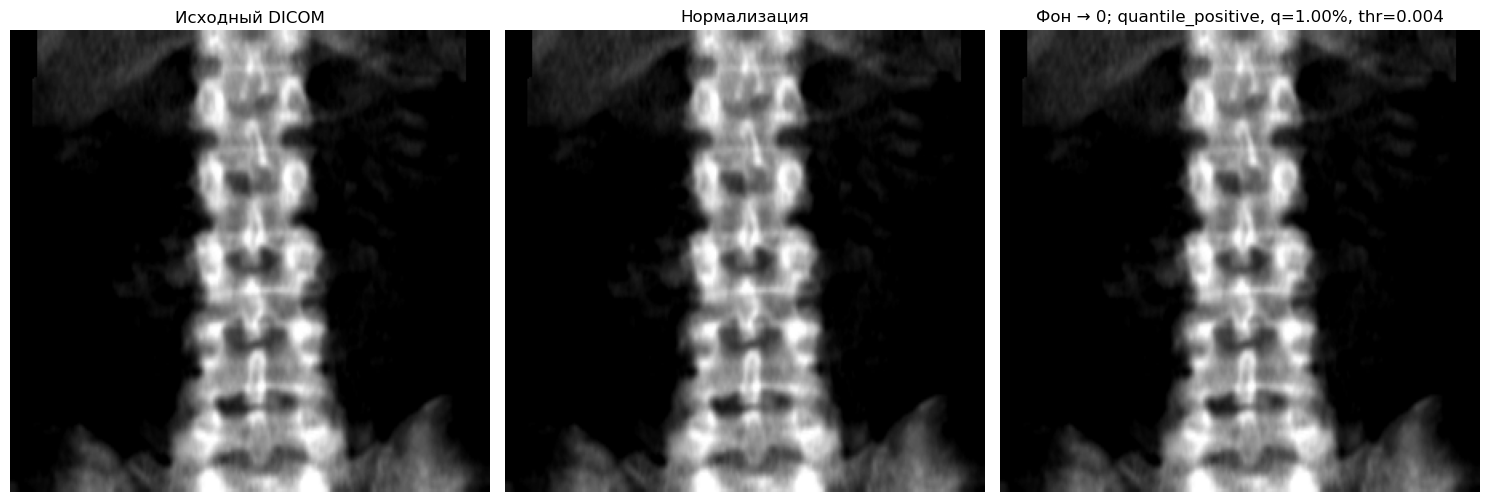

C:\Users\Андрей\Desktop\Хакатон\Исследования\1.2.840.113619.2.110.512719.20250403090444\series_004_3_CR\DXA\CR DXA\CR000001.dcm


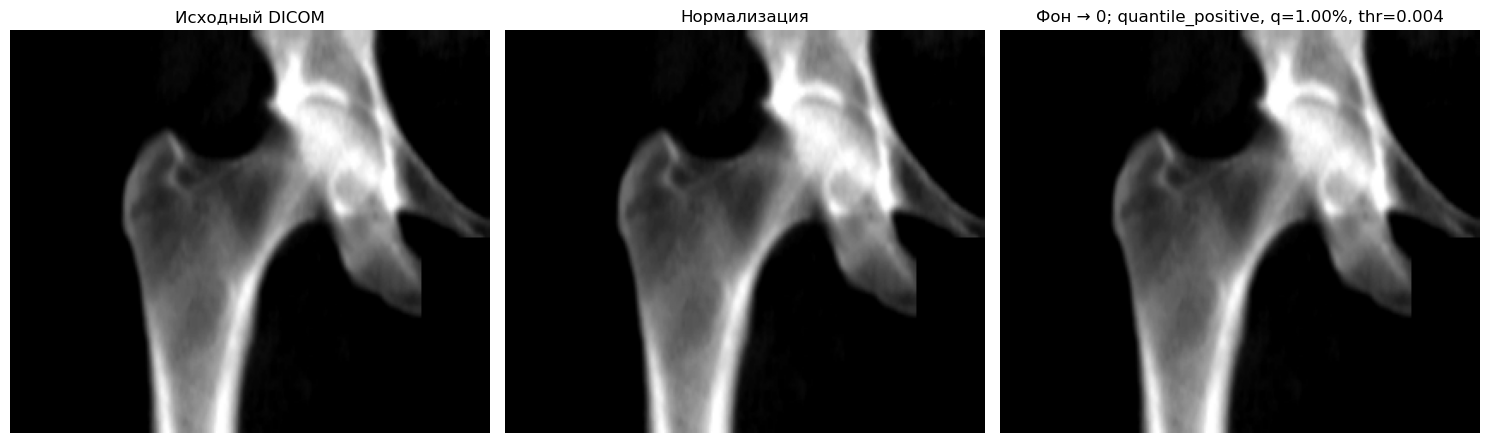

C:\Users\Андрей\Desktop\Хакатон\Исследования\1.2.840.113619.2.110.512719.20250403090444\series_004_3_CR\DXA\CR DXA\CR000002.dcm


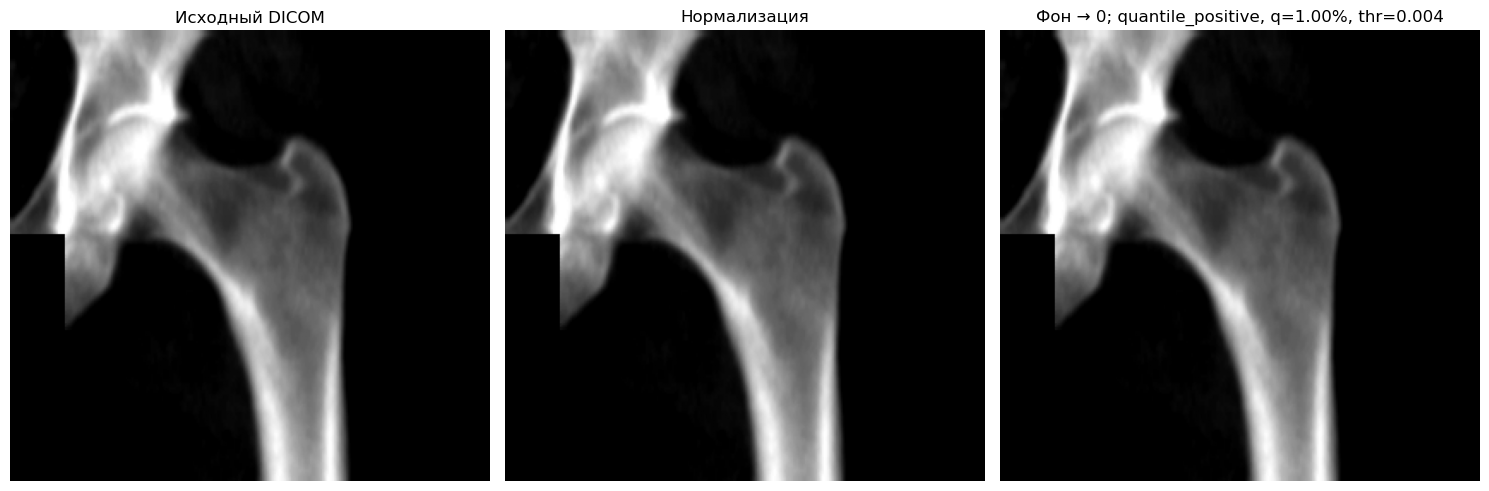

In [5]:
all_dicoms = sorted(STUDIES_ROOT.rglob("*.dcm"))
print("Найдено DICOM:", len(all_dicoms))

for path in all_dicoms[:3]:
    print(path)
    show_preprocessing(path)

## 3. Загрузка ручной разметки `LEG / SPINE`

In [6]:
def normalize_relative_path(value):
    return PurePosixPath(str(value).replace("\\", "/"))


def relative_to_local_path(relative_path):
    rel = normalize_relative_path(relative_path)
    return STUDIES_ROOT.joinpath(*rel.parts)


def load_all_manual_labels():
    csv_files = sorted(DATASET_ROOT.glob(LABEL_GLOB))

    if DEFAULT_LABELS_CSV.exists() and DEFAULT_LABELS_CSV not in csv_files:
        csv_files.append(DEFAULT_LABELS_CSV)

    if not csv_files:
        print("labels.csv не найден.")
        return pd.DataFrame()

    frames = []

    for csv_path in csv_files:
        df = pd.read_csv(csv_path, dtype=str).fillna("")

        if "relative_path" not in df.columns or "label" not in df.columns:
            warnings.warn(f"Пропускаю {csv_path}: нет relative_path/label")
            continue

        df["label_source"] = str(csv_path)
        frames.append(df)

    if not frames:
        return pd.DataFrame()

    all_labels = pd.concat(frames, ignore_index=True)
    all_labels = all_labels[
        all_labels["label"].isin(["LEG", "SPINE"])
    ].copy()

    conflicts = (
        all_labels.groupby("relative_path")["label"]
        .nunique()
        .loc[lambda s: s > 1]
    )

    if len(conflicts):
        print(
            f"Конфликтующие метки: {len(conflicts)} файлов. "
            "Исключаю их из обучения."
        )
        all_labels = all_labels[
            ~all_labels["relative_path"].isin(set(conflicts.index))
        ]

    all_labels = all_labels.drop_duplicates(
        subset=["relative_path", "label"]
    )

    all_labels["dicom_path"] = all_labels["relative_path"].map(
        relative_to_local_path
    )
    all_labels["exists"] = all_labels["dicom_path"].map(Path.exists)

    missing = int((~all_labels["exists"]).sum())
    if missing:
        print("Не найдено файлов из labels.csv:", missing)

    all_labels = all_labels[all_labels["exists"]].copy()
    all_labels["study_id"] = all_labels["relative_path"].map(
        lambda x: normalize_relative_path(x).parts[0]
    )

    return all_labels.reset_index(drop=True)


try:
    labels_df = load_all_manual_labels()
    display(labels_df.head())
    display(labels_df["label"].value_counts().to_frame("count"))
    print("Исследований:", labels_df["study_id"].nunique())
except:
    print("Разметка пока отсутствует.")

Не найдено файлов из labels.csv: 244


,relative_path,label,notes,annotator,annotated_at,output_path,label_source,dicom_path,exists,study_id
0,1.2.840.113619.2.110.512719.20250403090444/ser...,SPINE,,,2026-09-16T17:10:51,/output/1.2.840.113619.2.110.512719.2025040309...,C:\Users\Андрей\Desktop\Хакатон\Размеченные\la...,C:\Users\Андрей\Desktop\Хакатон\Исследования\1...,True,1.2.840.113619.2.110.512719.20250403090444
1,1.2.840.113619.2.110.512719.20250403090444/ser...,LEG,,,2026-09-16T17:10:53,/output/1.2.840.113619.2.110.512719.2025040309...,C:\Users\Андрей\Desktop\Хакатон\Размеченные\la...,C:\Users\Андрей\Desktop\Хакатон\Исследования\1...,True,1.2.840.113619.2.110.512719.20250403090444
2,1.2.840.113619.2.110.512719.20250403090444/ser...,LEG,,,2026-09-16T17:10:55,/output/1.2.840.113619.2.110.512719.2025040309...,C:\Users\Андрей\Desktop\Хакатон\Размеченные\la...,C:\Users\Андрей\Desktop\Хакатон\Исследования\1...,True,1.2.840.113619.2.110.512719.20250403090444
3,1.2.840.113619.2.110.512719.20250403090444/ser...,LEG,,,2026-09-16T17:10:58,/output/1.2.840.113619.2.110.512719.2025040309...,C:\Users\Андрей\Desktop\Хакатон\Размеченные\la...,C:\Users\Андрей\Desktop\Хакатон\Исследования\1...,True,1.2.840.113619.2.110.512719.20250403090444
4,1.2.840.113619.2.110.512719.20250403090444/ser...,LEG,,,2026-09-16T17:11:00,/output/1.2.840.113619.2.110.512719.2025040309...,C:\Users\Андрей\Desktop\Хакатон\Размеченные\la...,C:\Users\Андрей\Desktop\Хакатон\Исследования\1...,True,1.2.840.113619.2.110.512719.20250403090444


,count
label,
LEG,167
SPINE,85


Исследований: 50


## 4. ResNet: классификация `LEG / SPINE`

Разбиение выполняется по `study_id`, чтобы DICOM одного исследования не попали одновременно в train и validation.

In [7]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

train_transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


def dicom_to_pil(path):
    _, _, _, img, _ = preprocess_dicom(path)
    uint8 = (img * 255).clip(0, 255).astype(np.uint8)
    return Image.fromarray(uint8).convert("RGB")


class DicomClassificationDataset(Dataset):
    def __init__(self, frame, label_to_idx, transform):
        self.frame = frame.reset_index(drop=True)
        self.label_to_idx = label_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        image = self.transform(dicom_to_pil(row["dicom_path"]))
        target = self.label_to_idx[str(row["label"])]

        return {
            "image": image,
            "target": torch.tensor(target, dtype=torch.long),
            "path": str(row["dicom_path"]),
        }


def grouped_train_val_split(df, val_size=0.20):
    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=val_size,
        random_state=SEED,
    )

    train_idx, val_idx = next(
        splitter.split(df, y=df["label"], groups=df["study_id"])
    )

    return (
        df.iloc[train_idx].reset_index(drop=True),
        df.iloc[val_idx].reset_index(drop=True),
    )


def build_resnet18(num_classes=2):
    model = resnet18(weights=ResNet18_Weights.DEFAULT)

    for p in model.parameters():
        p.requires_grad = False

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


def class_weights_from_df(df, label_to_idx):
    counts = df["label"].value_counts()
    total = len(df)
    result = np.ones(len(label_to_idx), dtype=np.float32)

    for name, idx in label_to_idx.items():
        n = counts.get(name, 0)
        if n > 0:
            result[idx] = total / (len(label_to_idx) * n)

    return torch.tensor(result, dtype=torch.float32, device=DEVICE)


def make_grad_scaler(use_amp: bool):
    if not use_amp:
        return None

    try:
        return torch.amp.GradScaler("cuda", enabled=True)
    except Exception:
        try:
            return torch.amp.GradScaler(device="cuda", enabled=True)
        except Exception:
            return torch.cuda.amp.GradScaler(enabled=True)


def amp_context(use_amp: bool):
    if not use_amp:
        return nullcontext()

    try:
        return torch.amp.autocast(device_type="cuda", enabled=True)
    except Exception:
        return torch.cuda.amp.autocast(enabled=True)


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    losses, y_true, y_pred, y_prob = [], [], [], []
    use_amp = DEVICE.type == "cuda"
    scaler = make_grad_scaler(use_amp)

    grad_context = torch.enable_grad if is_train else torch.no_grad

    with grad_context():
        for batch in loader:
            x = batch["image"].to(DEVICE)
            y = batch["target"].to(DEVICE)

            if is_train:
                optimizer.zero_grad(set_to_none=True)

            with amp_context(use_amp):
                logits = model(x)
                loss = criterion(logits, y)

            if is_train:
                if use_amp:
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    optimizer.step()

            probs = torch.softmax(logits.detach(), dim=1)
            preds = probs.argmax(dim=1)

            losses.append(loss.item())
            y_true.extend(y.detach().cpu().numpy().tolist())
            y_pred.extend(preds.cpu().numpy().tolist())
            y_prob.extend(probs.cpu().numpy().tolist())

    metrics = {
        "loss": float(np.mean(losses)) if losses else np.nan,
        "balanced_acc": (
            balanced_accuracy_score(y_true, y_pred)
            if len(set(y_true)) > 1 else np.nan
        ),
        "f1_macro": (
            f1_score(y_true, y_pred, average="macro", zero_division=0)
            if y_true else np.nan
        ),
    }

    probs_np = np.asarray(y_prob)

    if len(set(y_true)) > 1 and probs_np.ndim == 2 and probs_np.shape[1] == 2:
        metrics["roc_auc"] = roc_auc_score(y_true, probs_np[:, 1])
    else:
        metrics["roc_auc"] = np.nan

    return metrics, np.asarray(y_true), np.asarray(y_pred), probs_np


def fit_classifier(train_df, val_df, label_to_idx):
    train_loader = DataLoader(
        DicomClassificationDataset(train_df, label_to_idx, train_transform),
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
    )

    val_loader = DataLoader(
        DicomClassificationDataset(val_df, label_to_idx, eval_transform),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
    )

    model = build_resnet18(len(label_to_idx)).to(DEVICE)
    criterion = nn.CrossEntropyLoss(
        weight=class_weights_from_df(train_df, label_to_idx)
    )

    history = []

    optimizer = torch.optim.AdamW(
        model.fc.parameters(), lr=1e-3, weight_decay=1e-4
    )

    for epoch in range(HEAD_EPOCHS):
        tr, *_ = run_epoch(model, train_loader, criterion, optimizer)
        va, y_true, y_pred, y_prob = run_epoch(model, val_loader, criterion)

        row = {
            "phase": "head",
            "epoch": epoch + 1,
            **{f"train_{k}": v for k, v in tr.items()},
            **{f"val_{k}": v for k, v in va.items()},
        }
        history.append(row)
        print(row)

    for p in model.layer4.parameters():
        p.requires_grad = True

    optimizer = torch.optim.AdamW(
        [
            {"params": model.layer4.parameters(), "lr": 1e-4},
            {"params": model.fc.parameters(), "lr": 3e-4},
        ],
        weight_decay=1e-4,
    )

    for epoch in range(FINETUNE_EPOCHS):
        tr, *_ = run_epoch(model, train_loader, criterion, optimizer)
        va, y_true, y_pred, y_prob = run_epoch(model, val_loader, criterion)

        row = {
            "phase": "finetune",
            "epoch": epoch + 1,
            **{f"train_{k}": v for k, v in tr.items()},
            **{f"val_{k}": v for k, v in va.items()},
        }
        history.append(row)
        print(row)

    return model, pd.DataFrame(history), (y_true, y_pred, y_prob)


def split_summary(frame, split_name):
    counts = frame["label"].value_counts().rename("count")
    out = counts.to_frame()
    out["share_%"] = (100 * out["count"] / len(frame)).round(2)
    print(
        f"{split_name}: {len(frame)} изображений, "
        f"{frame['study_id'].nunique()} исследований"
    )
    display(out)

In [8]:
spine_leg_model = None
spine_leg_label_to_idx = {"LEG": 0, "SPINE": 1}

if len(labels_df) >= 10 and labels_df["label"].nunique() == 2:
    train_df, val_df = grouped_train_val_split(labels_df)

    print("TRAIN")
    split_summary(train_df, "TRAIN")
    print("VAL")
    split_summary(val_df, "VAL")

    print(
        "Смысл чисел выше:\n"
        "- count = сколько DXA попало в данный split;\n"
        "- share_% = доля класса внутри split;\n"
        "- TRAIN используется для обучения модели;\n"
        "- VAL не участвует в обучении и нужен для проверки качества."
    )

    spine_leg_model, history_df, val_outputs = fit_classifier(
        train_df, val_df, spine_leg_label_to_idx
    )

    display(history_df)

    y_true, y_pred, y_prob = val_outputs

    print(classification_report(
        y_true, y_pred,
        target_names=["LEG", "SPINE"],
        zero_division=0,
    ))
    print(confusion_matrix(y_true, y_pred))

    torch.save(
        {
            "state_dict": spine_leg_model.state_dict(),
            "label_to_idx": spine_leg_label_to_idx,
        },
        WORK_DIR / "resnet18_leg_spine.pt",
    )
else:
    print("Недостаточно LEG/SPINE-разметки для обучения.")

TRAIN
TRAIN: 209 изображений, 40 исследований


,count,share_%
label,,
LEG,139,66.51
SPINE,70,33.49


VAL
VAL: 43 изображений, 10 исследований


,count,share_%
label,,
LEG,28,65.12
SPINE,15,34.88


Смысл чисел выше:
- count = сколько DXA попало в данный split;
- share_% = доля класса внутри split;
- TRAIN используется для обучения модели;
- VAL не участвует в обучении и нужен для проверки качества.
{'phase': 'head', 'epoch': 1, 'train_loss': 0.4587915050131934, 'train_balanced_acc': 0.8243576567317574, 'train_f1_macro': 0.8092736465655445, 'train_roc_auc': 0.9261048304213773, 'val_loss': 0.25211558242638904, 'val_balanced_acc': 0.9107142857142857, 'val_f1_macro': 0.8795518207282913, 'val_roc_auc': 1.0}
{'phase': 'head', 'epoch': 2, 'train_loss': 0.1509979228888239, 'train_balanced_acc': 1.0, 'train_f1_macro': 1.0, 'train_roc_auc': 1.0, 'val_loss': 0.10922721773386002, 'val_balanced_acc': 1.0, 'val_f1_macro': 1.0, 'val_roc_auc': 1.0}
{'phase': 'head', 'epoch': 3, 'train_loss': 0.10945836108710084, 'train_balanced_acc': 0.9857142857142858, 'train_f1_macro': 0.9891821946169772, 'train_roc_auc': 1.0, 'val_loss': 0.05148765568931898, 'val_balanced_acc': 1.0, 'val_f1_macro': 1.0, 'val_

,phase,epoch,train_loss,train_balanced_acc,train_f1_macro,train_roc_auc,val_loss,val_balanced_acc,val_f1_macro,val_roc_auc
0,head,1,0.458792,0.824358,0.809274,0.926105,0.252116,0.910714,0.879552,1.0
1,head,2,0.150998,1.000000,1.000000,1.000000,0.109227,1.000000,1.000000,1.0
2,head,3,0.109458,0.985714,0.989182,1.000000,0.051488,1.000000,1.000000,1.0
3,finetune,1,0.041842,1.000000,1.000000,1.000000,0.035221,0.982143,0.974780,1.0
4,finetune,2,0.015574,1.000000,1.000000,1.000000,0.002767,1.000000,1.000000,1.0
5,finetune,3,0.104483,0.992857,0.994611,1.000000,0.000051,1.000000,1.000000,1.0
6,finetune,4,0.014866,1.000000,1.000000,1.000000,0.000083,1.000000,1.000000,1.0
7,finetune,5,0.106632,0.992857,0.994611,1.000000,0.000025,1.000000,1.000000,1.0


              precision    recall  f1-score   support

         LEG       1.00      1.00      1.00        28
       SPINE       1.00      1.00      1.00        15

    accuracy                           1.00        43
   macro avg       1.00      1.00      1.00        43
weighted avg       1.00      1.00      1.00        43

[[28  0]
 [ 0 15]]


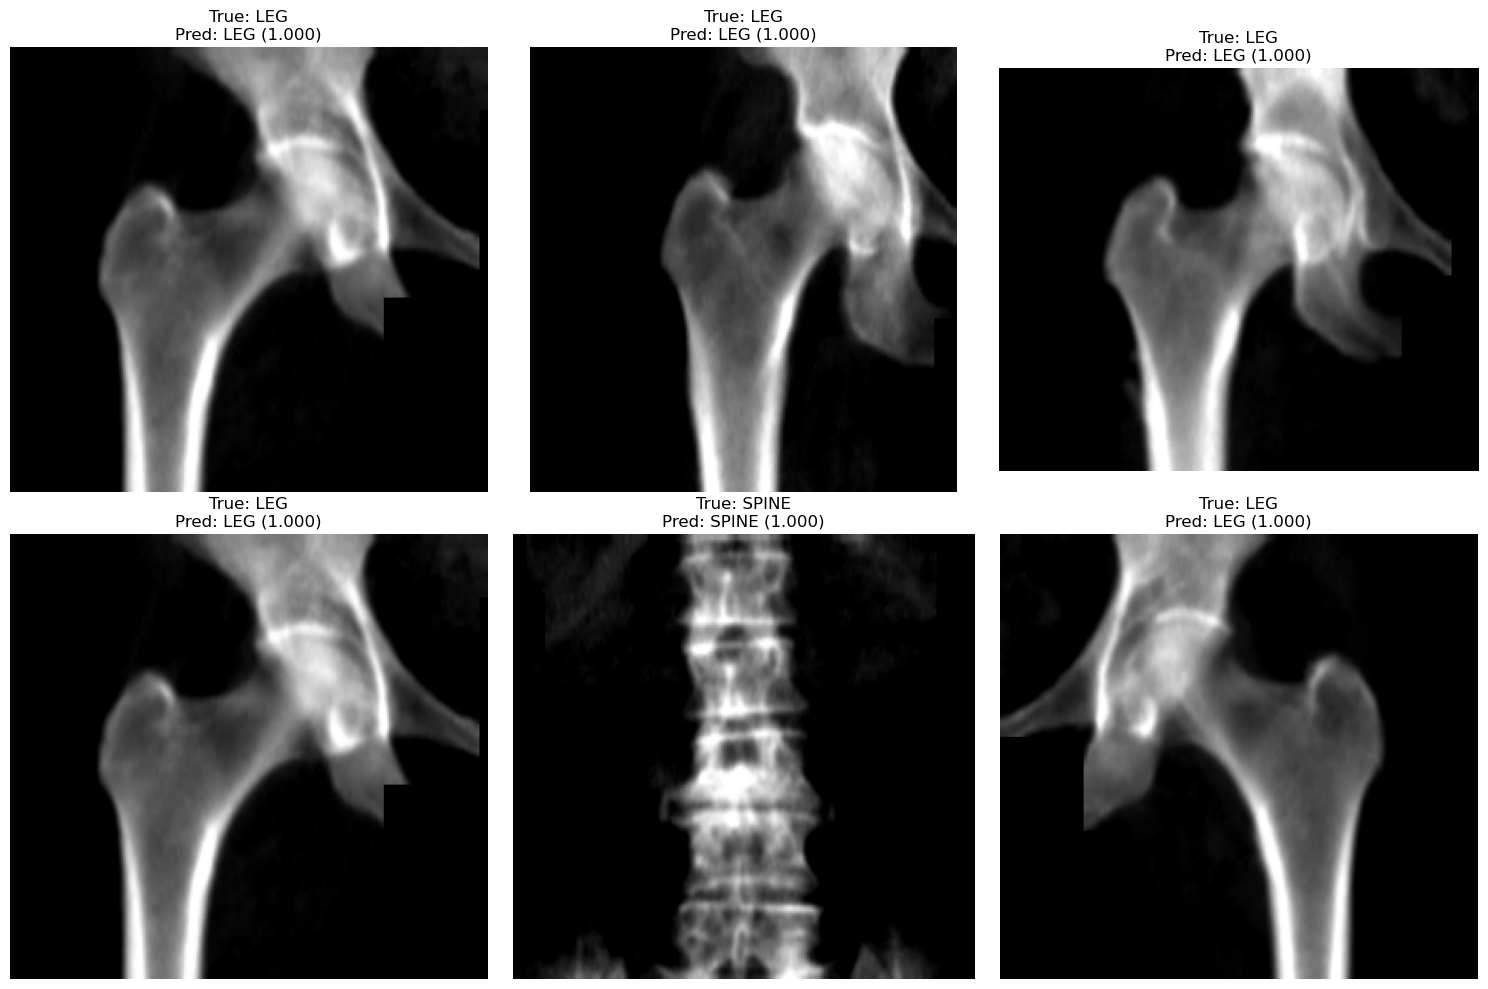

In [9]:
@torch.no_grad()
def show_classification_examples(model, frame, label_to_idx, n=6):
    idx_to_label = {v: k for k, v in label_to_idx.items()}

    sample = frame.sample(min(n, len(frame)), random_state=SEED)

    cols = 3
    rows = math.ceil(len(sample) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = np.asarray(axes).reshape(-1)

    for ax, (_, row) in zip(axes, sample.iterrows()):
        pil = dicom_to_pil(row["dicom_path"])
        x = eval_transform(pil).unsqueeze(0).to(DEVICE)

        probs = torch.softmax(model(x), dim=1)[0].cpu().numpy()
        pred_idx = int(np.argmax(probs))
        pred = idx_to_label[pred_idx]

        _, _, _, img, _ = preprocess_dicom(row["dicom_path"])

        ax.imshow(img, cmap="gray")
        ax.set_title(
            f"True: {row['label']}\nPred: {pred} ({probs[pred_idx]:.3f})"
        )
        ax.axis("off")

    for ax in axes[len(sample):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


if spine_leg_model is not None:
    show_classification_examples(
        spine_leg_model, val_df, spine_leg_label_to_idx, n=6
    )

## 5. Бедро — металл

Создаётся отдельный `metal_labels.csv` для изображений `LEG`.

Формат: `relative_path, metal`, где `metal` = `0` или `1`.

После заполнения используется тот же ResNet-пайплайн.

In [10]:
if len(labels_df):
    leg_rows = labels_df[labels_df["label"] == "LEG"].copy()

    if not METAL_LABELS_CSV.exists():
        template = leg_rows[["relative_path"]].copy()
        template["metal"] = ""
        template.to_csv(METAL_LABELS_CSV, index=False, encoding="utf-8-sig")
        print("Создан шаблон:", METAL_LABELS_CSV)
    else:
        print("Файл уже существует:", METAL_LABELS_CSV)

Файл уже существует: C:\Users\Андрей\Desktop\Хакатон\metal_labels.csv


In [11]:
metal_model = None

if METAL_LABELS_CSV.exists():
    metal_df = pd.read_csv(METAL_LABELS_CSV, dtype=str).fillna("")
    metal_df = metal_df[metal_df["metal"].isin(["0", "1"])].copy()

    if len(metal_df):
        metal_df["label"] = metal_df["metal"].map(
            {"0": "NO_METAL", "1": "METAL"}
        )
        metal_df["dicom_path"] = metal_df["relative_path"].map(
            relative_to_local_path
        )
        metal_df = metal_df[metal_df["dicom_path"].map(Path.exists)].copy()
        metal_df["study_id"] = metal_df["relative_path"].map(
            lambda x: normalize_relative_path(x).parts[0]
        )

        display(metal_df["label"].value_counts().to_frame())

        if len(metal_df) >= 10 and metal_df["label"].nunique() == 2:
            metal_train_df, metal_val_df = grouped_train_val_split(metal_df)

            metal_label_to_idx = {"NO_METAL": 0, "METAL": 1}

            metal_model, metal_history, _ = fit_classifier(
                metal_train_df, metal_val_df, metal_label_to_idx
            )

            display(metal_history)

            torch.save(
                {
                    "state_dict": metal_model.state_dict(),
                    "label_to_idx": metal_label_to_idx,
                },
                WORK_DIR / "resnet18_metal.pt",
            )

            show_classification_examples(
                metal_model, metal_val_df, metal_label_to_idx, n=6
            )
        else:
            print("Пока мало заполненных 0/1 или присутствует один класс.")

## 6. Бедро — грубая маска для геометрических проверок

Это не финальная сегментация. Маска нужна только для прототипа угловых эвристик.

In [12]:
def keep_reasonable_components(mask, min_fraction=0.002):
    labeled = cc_label(mask)
    out = np.zeros_like(mask, dtype=bool)
    min_area = int(mask.size * min_fraction)

    for region in regionprops(labeled):
        if region.area >= min_area:
            out[labeled == region.label] = True

    return out


def rough_bone_mask(img01):
    positive = img01[img01 > 0]

    if len(positive) == 0:
        return np.zeros_like(img01, dtype=bool)

    try:
        threshold = threshold_otsu(positive)
    except Exception:
        threshold = np.quantile(positive, 0.5)

    mask = img01 >= threshold
    mask = binary_closing(mask, disk(2))
    mask = remove_small_objects(mask, min_size=max(64, int(mask.size * 0.001)))
    mask = remove_small_holes(mask, area_threshold=max(64, int(mask.size * 0.001)))
    return keep_reasonable_components(mask)


def mask_bbox(mask, pad=5):
    ys, xs = np.where(mask)

    if len(xs) == 0:
        return 0, 0, mask.shape[1], mask.shape[0]

    return (
        max(0, xs.min() - pad),
        max(0, ys.min() - pad),
        min(mask.shape[1], xs.max() + pad + 1),
        min(mask.shape[0], ys.max() + pad + 1),
    )


def canonicalize_hip(img, mask):
    h, w = mask.shape
    lower = mask[int(h * 0.55):]
    col_counts = lower.sum(axis=0)

    if col_counts.max() == 0:
        return img, mask, False

    shaft_x = int(np.argmax(col_counts))
    do_flip = shaft_x < w / 2

    if do_flip:
        return np.fliplr(img), np.fliplr(mask), True

    return img, mask, False

## 7. Бедро — три if-проверки с перебором углов

Для каждой из трёх областей:

- берём skeleton кости;
- перебираем точки skeleton внутри ROI;
- перебираем углы;
- для каждой линии измеряем непрерывную ширину кости;
- выбираем минимальную ширину;
- сравниваем найденный угол с ожидаемым из схемы.

In [13]:
def angle_diff_deg(a, b):
    return abs(a - b)


def roi_pixels_from_fraction(mask, roi):
    x0, y0, x1, y1 = mask_bbox(mask)
    bw, bh = x1 - x0, y1 - y0
    rx0, ry0, rx1, ry1 = roi

    return (
        int(x0 + rx0 * bw),
        int(y0 + ry0 * bh),
        int(x0 + rx1 * bw),
        int(y0 + ry1 * bh),
    )


def crop_roi(img, roi_px):
    x0, y0, x1, y1 = roi_px
    return img[y0:y1, x0:x1]


def rotate_for_vertical_projection(roi_img, angle_from_vertical_deg):
    # Угол задан относительно вертикали.
    # Поворачиваем ROI так, чтобы искомое направление стало вертикальным,
    # затем считаем проекцию как сумму по столбцам.
    return ndi_rotate(
        roi_img,
        angle=angle_from_vertical_deg,
        reshape=False,
        order=1,
        mode="constant",
        cval=0.0,
    )


def projection_profile_for_angle(roi_img, angle_from_vertical_deg):
    rotated = rotate_for_vertical_projection(
        roi_img,
        angle_from_vertical_deg,
    )

    profile = rotated.sum(axis=0).astype(np.float32)
    smooth = gaussian_filter1d(
        profile,
        sigma=max(1.0, len(profile) / 70),
    )

    return rotated, profile, smooth


def candidate_minima(profile, eps_fraction=0.02):
    if len(profile) == 0:
        return np.array([], dtype=int)

    eps = float(profile.max()) * eps_fraction
    minima, _ = find_peaks(
        -profile,
        distance=max(3, len(profile) // 20),
    )

    minima = minima[
        profile[minima] > eps
    ]

    return minima.astype(int)


def choose_valley(profile, rule):
    profile = np.asarray(profile, dtype=np.float32)

    if len(profile) == 0 or np.all(profile <= 0):
        return None

    peak_idx = int(np.argmax(profile))
    minima = candidate_minima(profile)

    if len(minima) == 0:
        nonzero = np.where(profile > 0)[0]
        if len(nonzero) == 0:
            return None
        minima = nonzero

    if rule == "left_of_peak":
        candidates = minima[minima < peak_idx]
        if len(candidates) == 0:
            return None
        valley_idx = int(candidates[np.argmin(profile[candidates])])

    elif rule == "right_of_peak":
        candidates = minima[minima > peak_idx]
        if len(candidates) == 0:
            return None
        valley_idx = int(candidates[np.argmin(profile[candidates])])

    elif rule == "nearest_to_center":
        center = len(profile) / 2
        candidates = minima
        score = np.abs(candidates - center) / max(1.0, len(profile)) + \
            0.25 * (profile[candidates] / max(profile.max(), 1e-6))
        valley_idx = int(candidates[np.argmin(score)])

    else:
        raise ValueError(f"Unknown rule: {rule}")

    peak_val = float(profile[peak_idx])
    valley_val = float(profile[valley_idx])
    contrast = peak_val - valley_val

    return {
        "peak_idx": peak_idx,
        "peak_val": peak_val,
        "valley_idx": valley_idx,
        "valley_val": valley_val,
        "contrast": contrast,
    }


def evaluate_projection_rule(roi_img, angle_from_vertical_deg, rule):
    rotated, raw_profile, smooth_profile = projection_profile_for_angle(
        roi_img,
        angle_from_vertical_deg,
    )

    valley = choose_valley(
        smooth_profile,
        rule=rule,
    )

    if valley is None:
        return None

    return {
        "angle_vertical": float(angle_from_vertical_deg),
        "rotated_roi": rotated,
        "raw_profile": raw_profile,
        "smooth_profile": smooth_profile,
        **valley,
    }


def angle_sweep_projection_rule(roi_img, expected_angle_vertical, rule):
    angles = np.arange(
        expected_angle_vertical - HIP_ANGLE_HALF_RANGE,
        expected_angle_vertical + HIP_ANGLE_HALF_RANGE + 1e-9,
        HIP_ANGLE_STEP,
    )

    records = []

    for angle in angles:
        result = evaluate_projection_rule(
            roi_img=roi_img,
            angle_from_vertical_deg=angle,
            rule=rule,
        )

        if result is None:
            records.append({
                "angle_vertical": float(angle),
                "contrast": np.nan,
                "peak_idx": np.nan,
                "valley_idx": np.nan,
                "peak_val": np.nan,
                "valley_val": np.nan,
            })
        else:
            records.append({
                "angle_vertical": result["angle_vertical"],
                "contrast": result["contrast"],
                "peak_idx": result["peak_idx"],
                "valley_idx": result["valley_idx"],
                "peak_val": result["peak_val"],
                "valley_val": result["valley_val"],
            })

    frame = pd.DataFrame(records)
    frame = frame[np.isfinite(frame["contrast"])].copy()

    if frame.empty:
        return None

    best_angle = float(
        frame.loc[frame["contrast"].idxmax(), "angle_vertical"]
    )

    best = evaluate_projection_rule(
        roi_img=roi_img,
        angle_from_vertical_deg=best_angle,
        rule=rule,
    )

    return {
        "records": frame.reset_index(drop=True),
        "best_angle_vertical": best["angle_vertical"],
        "best_contrast": best["contrast"],
        "peak_idx": best["peak_idx"],
        "valley_idx": best["valley_idx"],
        "peak_val": best["peak_val"],
        "valley_val": best["valley_val"],
        "rotated_roi": best["rotated_roi"],
        "profile": best["smooth_profile"],
    }


def analyze_hip_position(path):
    _, _, _, img, _ = preprocess_dicom(path)
    mask = rough_bone_mask(img)
    img, mask, flipped = canonicalize_hip(img, mask)

    results = {}

    for key in ("1", "2", "3"):
        roi_px = roi_pixels_from_fraction(mask, HIP_ROIS[key])
        roi_img = crop_roi(img, roi_px)

        result = angle_sweep_projection_rule(
            roi_img=roi_img,
            expected_angle_vertical=HIP_EXPECTED_VERTICAL_ANGLES[key],
            rule=HIP_SEARCH_RULES[key],
        )

        if result is not None:
            result["roi_px"] = roi_px
            result["expected_angle_vertical"] = HIP_EXPECTED_VERTICAL_ANGLES[key]
            result["search_rule"] = HIP_SEARCH_RULES[key]
            result["angle_error"] = angle_diff_deg(
                result["best_angle_vertical"],
                result["expected_angle_vertical"],
            )
            result["passed"] = (
                result["angle_error"] <= HIP_ANGLE_TOLERANCE
            )

        results[key] = result

    return img, mask, flipped, results


def plot_hip_position_analysis(path):
    img, mask, flipped, results = analyze_hip_position(path)

    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(2, 2, width_ratios=[1.1, 1.0], height_ratios=[1.0, 1.0])

    ax_img = fig.add_subplot(gs[:, 0])
    ax_curve = fig.add_subplot(gs[0, 1])
    ax_prof1 = fig.add_subplot(gs[1, 1])

    ax_img.imshow(img, cmap="gray")
    ax_img.imshow(mask, alpha=0.18)
    ax_img.set_title(f"ROI бедра; flipped={flipped}")
    ax_img.axis("off")

    colors = {"1": "tab:red", "2": "tab:green", "3": "tab:blue"}
    summary = []

    first_profile_plotted = False

    for key, result in results.items():
        color = colors[key]

        if result is None:
            summary.append({"check": key, "status": "NOT_FOUND"})
            continue

        x0, y0, x1, y1 = result["roi_px"]
        ax_img.add_patch(plt.Rectangle(
            (x0, y0), x1 - x0, y1 - y0,
            fill=False, linewidth=2, edgecolor=color
        ))
        ax_img.text(
            x0, y0 - 3,
            f"{key}: {result['best_angle_vertical']:.1f}°",
            color=color,
            fontsize=10,
        )

        frame = result["records"]
        ax_curve.plot(
            frame["angle_vertical"],
            frame["contrast"],
            marker=".",
            label=f"ROI {key}",
            color=color,
        )
        ax_curve.axvline(
            result["expected_angle_vertical"],
            linestyle="--",
            alpha=0.35,
            color=color,
        )

        if not first_profile_plotted:
            profile = result["profile"]
            peak_idx = int(result["peak_idx"])
            valley_idx = int(result["valley_idx"])

            ax_prof1.plot(profile, color=color)
            ax_prof1.scatter([peak_idx], [profile[peak_idx]], s=45, label="peak", color="black")
            ax_prof1.scatter([valley_idx], [profile[valley_idx]], s=45, label="valley", color="orange")
            ax_prof1.set_title(
                f"Пример профиля ROI {key}; правило={result['search_rule']}"
            )
            ax_prof1.set_xlabel("Индекс проекции")
            ax_prof1.set_ylabel("Сумма интенсивности")
            ax_prof1.legend()
            first_profile_plotted = True

        summary.append({
            "check": key,
            "best_angle_vertical": result["best_angle_vertical"],
            "expected_vertical": result["expected_angle_vertical"],
            "angle_error": result["angle_error"],
            "contrast": result["best_contrast"],
            "rule": result["search_rule"],
            "status": "PASS" if result["passed"] else "FAIL",
        })

    ax_curve.set_xlabel("Угол относительно вертикали, °")
    ax_curve.set_ylabel("Контраст max - valley")
    ax_curve.set_title("Перебор углов по проекции")
    ax_curve.grid(alpha=0.25)
    ax_curve.legend()

    plt.tight_layout()
    plt.show()

    return pd.DataFrame(summary)


2.25.156021661584944120526934974594604520993/series_003_2_CR/A2507142228 DXA/CR DXA/CR000007.dcm


C:\Temp\ipykernel_23460\1157129473.py:25: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  mask = binary_closing(mask, disk(2))
C:\Temp\ipykernel_23460\1157129473.py:26: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask = remove_small_objects(mask, min_size=max(64, int(mask.size * 0.001)))
C:\Temp\ipykernel_23460\1157129473.py:27: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation 

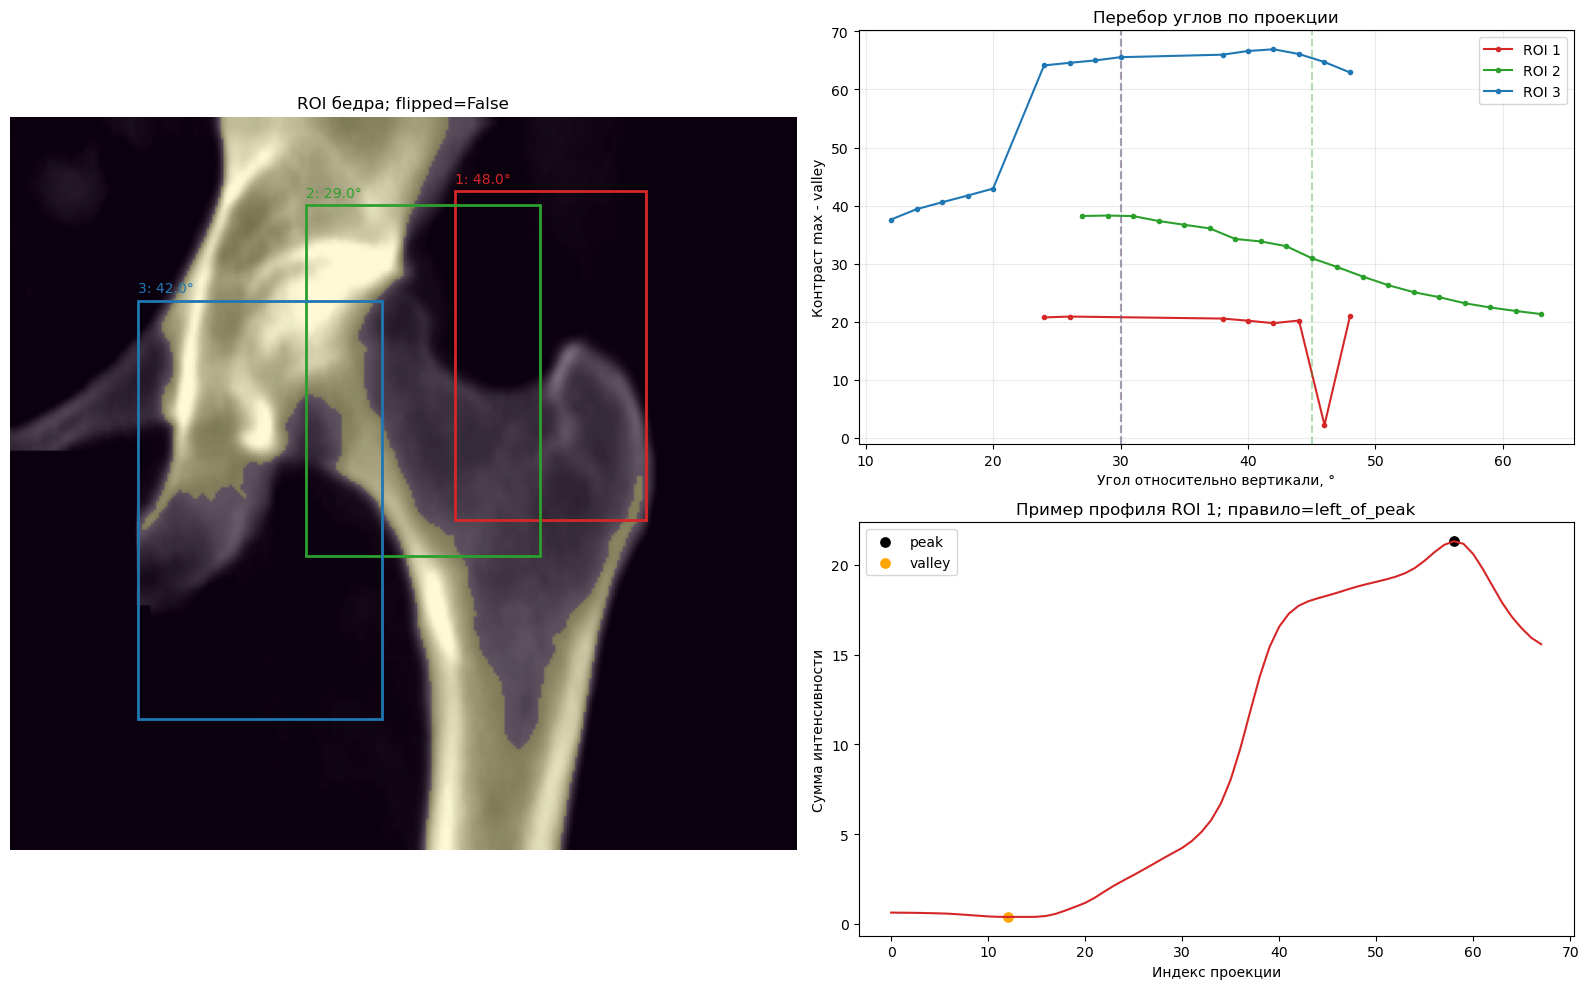

,check,best_angle_vertical,expected_vertical,angle_error,contrast,rule,status
0,1,48.0,30.0,18.0,20.939184,left_of_peak,FAIL
1,2,29.0,45.0,16.0,38.292097,nearest_to_center,FAIL
2,3,42.0,30.0,12.0,66.919810,right_of_peak,PASS



2.25.156375884487675936513403083218009333856/series_003_2_CR/A250727121 DXA/CR DXA/CR000006.dcm


C:\Temp\ipykernel_23460\1157129473.py:25: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  mask = binary_closing(mask, disk(2))
C:\Temp\ipykernel_23460\1157129473.py:26: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask = remove_small_objects(mask, min_size=max(64, int(mask.size * 0.001)))
C:\Temp\ipykernel_23460\1157129473.py:27: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation 

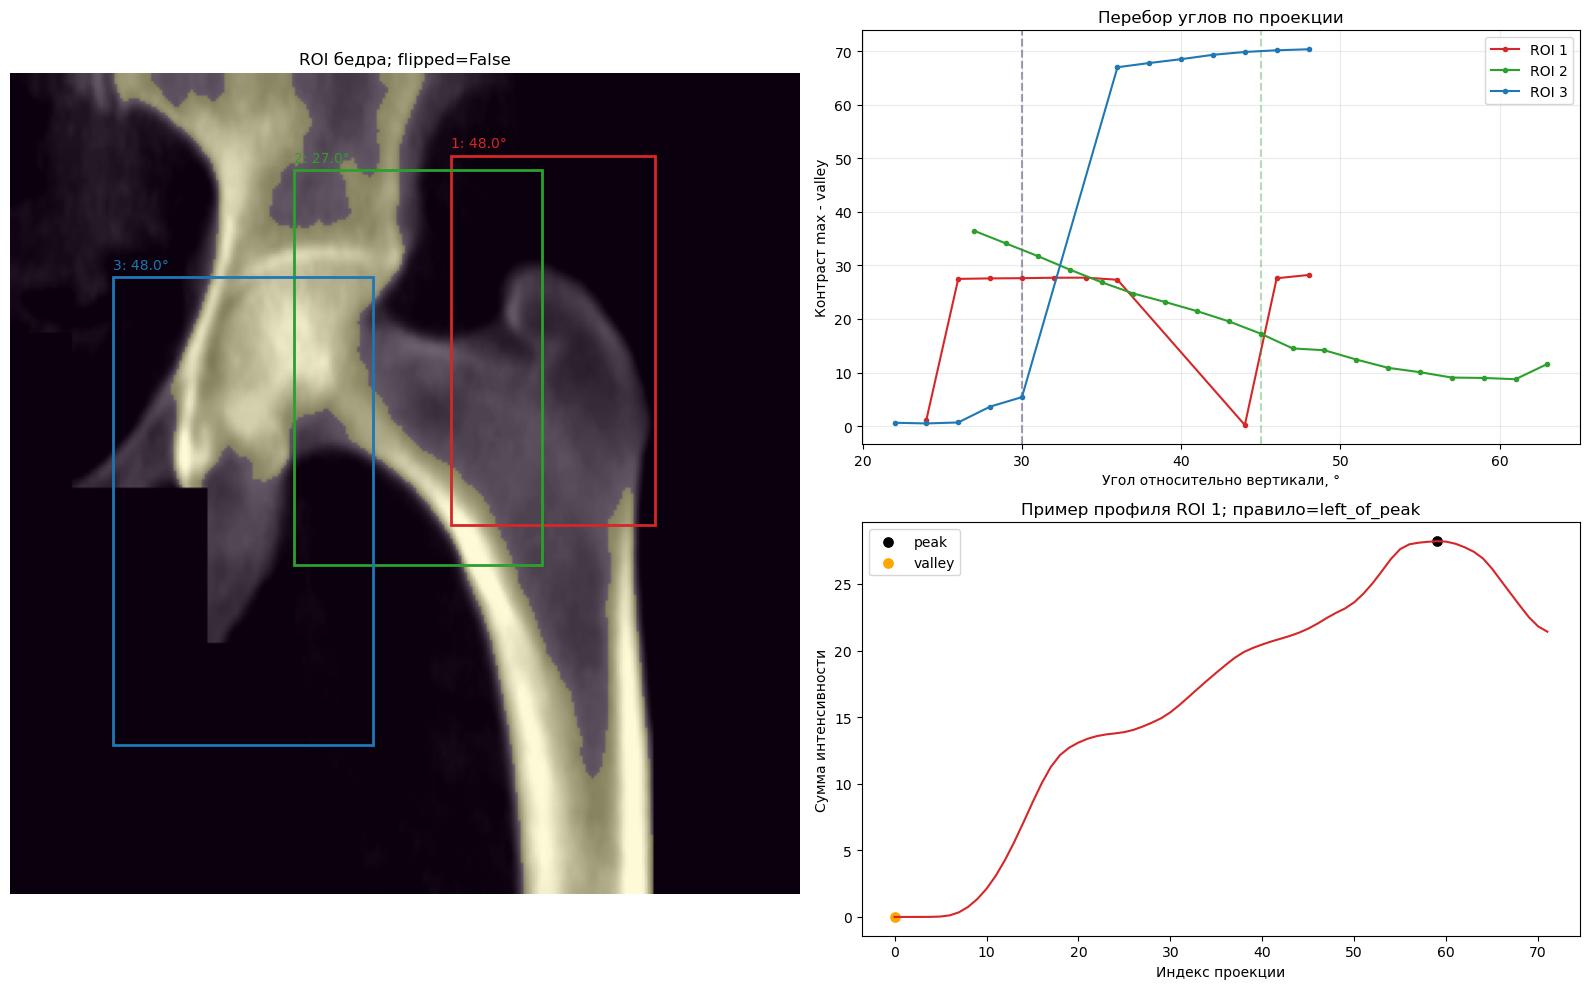

,check,best_angle_vertical,expected_vertical,angle_error,contrast,rule,status
0,1,48.0,30.0,18.0,28.211912,left_of_peak,FAIL
1,2,27.0,45.0,18.0,36.460571,nearest_to_center,FAIL
2,3,48.0,30.0,18.0,70.344071,right_of_peak,FAIL



2.25.137344827330550141320158285144101816664/series_003_3_CR/A2507146630 DXA/CR DXA/CR000002.dcm


C:\Temp\ipykernel_23460\1157129473.py:25: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  mask = binary_closing(mask, disk(2))
C:\Temp\ipykernel_23460\1157129473.py:26: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask = remove_small_objects(mask, min_size=max(64, int(mask.size * 0.001)))
C:\Temp\ipykernel_23460\1157129473.py:27: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation 

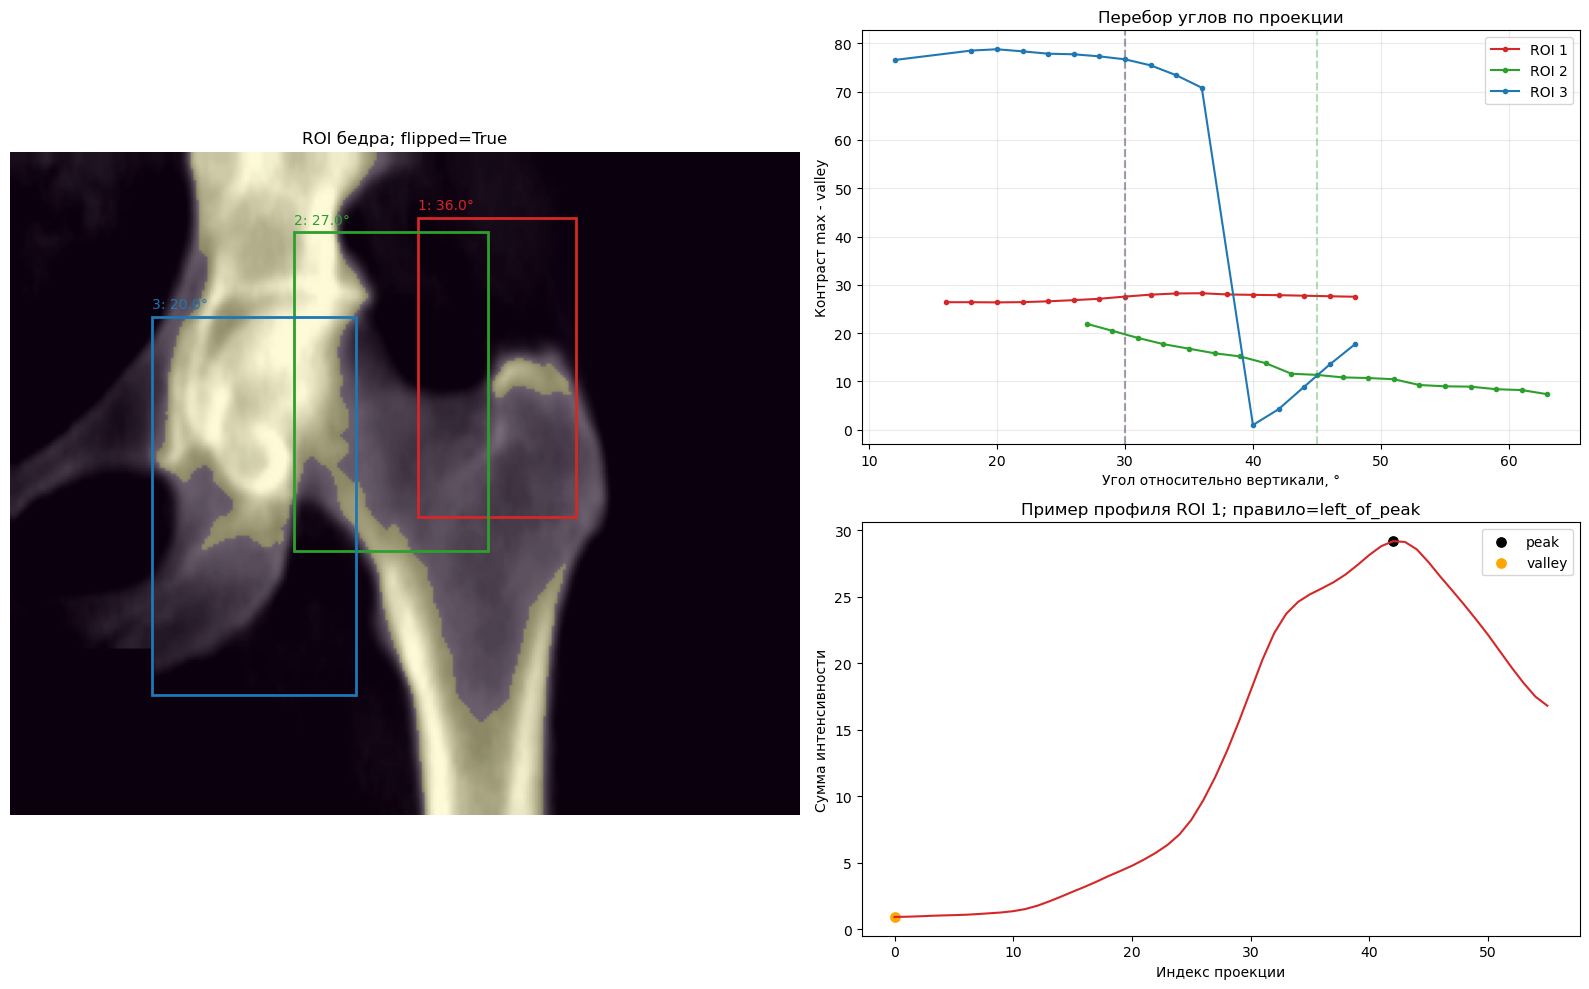

,check,best_angle_vertical,expected_vertical,angle_error,contrast,rule,status
0,1,36.0,30.0,6.0,28.259680,left_of_peak,PASS
1,2,27.0,45.0,18.0,21.944149,nearest_to_center,FAIL
2,3,20.0,30.0,10.0,78.756026,right_of_peak,PASS


In [14]:
leg_examples = pd.DataFrame()

if len(labels_df):
    leg_pool = labels_df[labels_df["label"] == "LEG"]

    if len(leg_pool):
        leg_examples = leg_pool.sample(
            min(3, len(leg_pool)), random_state=SEED
        )

        for _, row in leg_examples.iterrows():
            print("\n", "=" * 100)
            print(row["relative_path"])
            display(plot_hip_position_analysis(row["dicom_path"]))

## 8. Бедро — ротация ("горбик")

Ищем максимальный локальный поворот внешнего контура в верхне-правой ROI.  
Порог нормы не задаётся: в заметках он пока не определён.

2.25.156021661584944120526934974594604520993/series_003_2_CR/A2507142228 DXA/CR DXA/CR000007.dcm


C:\Temp\ipykernel_23460\1157129473.py:25: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  mask = binary_closing(mask, disk(2))
C:\Temp\ipykernel_23460\1157129473.py:26: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask = remove_small_objects(mask, min_size=max(64, int(mask.size * 0.001)))
C:\Temp\ipykernel_23460\1157129473.py:27: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation 

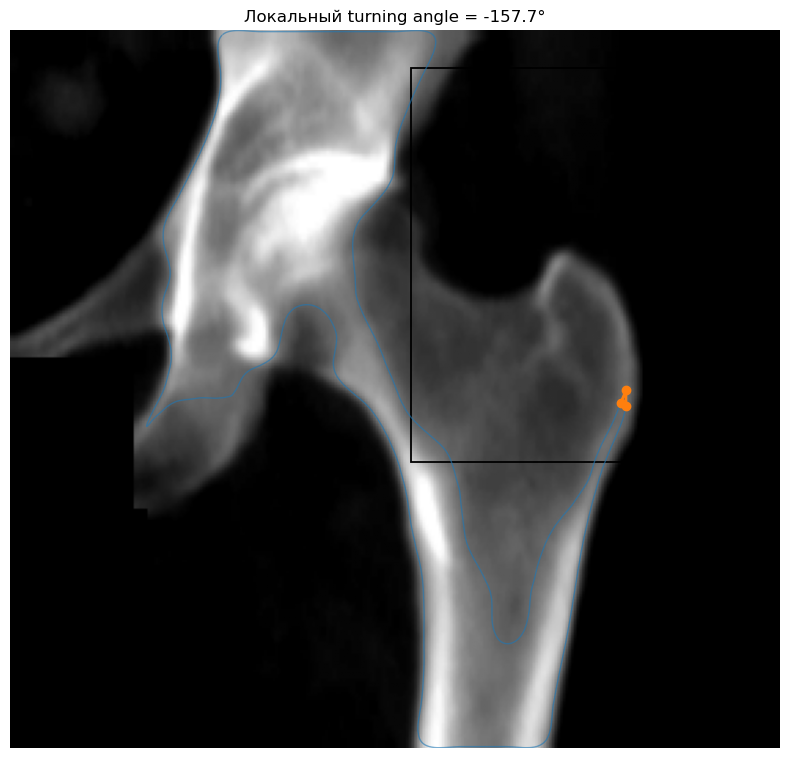

2.25.156375884487675936513403083218009333856/series_003_2_CR/A250727121 DXA/CR DXA/CR000006.dcm


C:\Temp\ipykernel_23460\1157129473.py:25: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  mask = binary_closing(mask, disk(2))
C:\Temp\ipykernel_23460\1157129473.py:26: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask = remove_small_objects(mask, min_size=max(64, int(mask.size * 0.001)))
C:\Temp\ipykernel_23460\1157129473.py:27: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation 

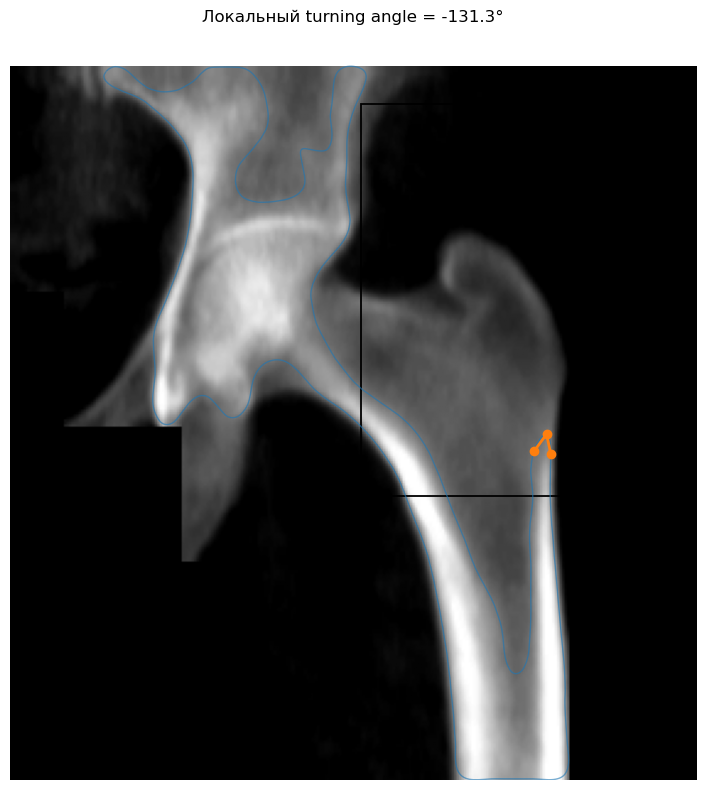

2.25.137344827330550141320158285144101816664/series_003_3_CR/A2507146630 DXA/CR DXA/CR000002.dcm


C:\Temp\ipykernel_23460\1157129473.py:25: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  mask = binary_closing(mask, disk(2))
C:\Temp\ipykernel_23460\1157129473.py:26: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask = remove_small_objects(mask, min_size=max(64, int(mask.size * 0.001)))
C:\Temp\ipykernel_23460\1157129473.py:27: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation 

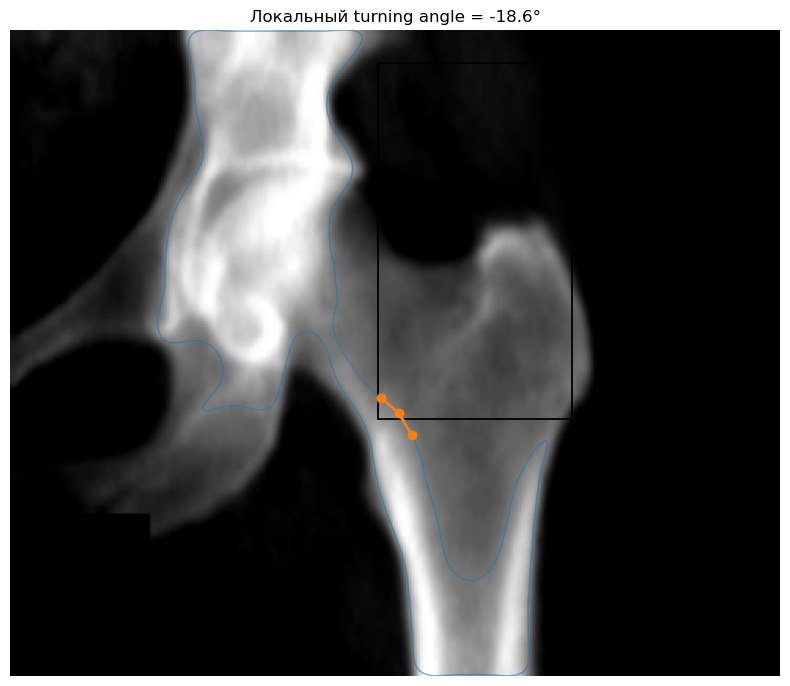

In [15]:
def largest_external_contour(mask):
    contours, _ = cv2.findContours(
        mask.astype(np.uint8),
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_NONE,
    )

    if not contours:
        return None

    return max(contours, key=cv2.contourArea)[:, 0, :].astype(np.float32)


def local_turning_angle(points, idx, window=12):
    n = len(points)
    p_prev = points[(idx - window) % n]
    p = points[idx]
    p_next = points[(idx + window) % n]

    v1 = p - p_prev
    v2 = p_next - p

    n1, n2 = np.linalg.norm(v1), np.linalg.norm(v2)

    if n1 == 0 or n2 == 0:
        return np.nan

    v1, v2 = v1 / n1, v2 / n2

    cross = v1[0] * v2[1] - v1[1] * v2[0]
    dot = np.clip(np.dot(v1, v2), -1, 1)

    return float(np.rad2deg(np.arctan2(cross, dot)))


def analyze_hip_bump(path, roi=(0.55, 0.05, 1.00, 0.60)):
    _, _, _, img, _ = preprocess_dicom(path)
    mask = rough_bone_mask(img)
    img, mask, flipped = canonicalize_hip(img, mask)

    contour = largest_external_contour(mask)

    if contour is None or len(contour) < 30:
        return None

    win = min(31, len(contour) - 1)
    if win % 2 == 0:
        win -= 1
    if win < 7:
        return None

    smooth = contour.copy()
    smooth[:, 0] = savgol_filter(
        contour[:, 0], win, 2, mode="wrap"
    )
    smooth[:, 1] = savgol_filter(
        contour[:, 1], win, 2, mode="wrap"
    )

    x0, y0, x1, y1 = mask_bbox(mask)
    bw, bh = x1 - x0, y1 - y0
    rx0, ry0, rx1, ry1 = roi

    ax0, ax1 = x0 + rx0 * bw, x0 + rx1 * bw
    ay0, ay1 = y0 + ry0 * bh, y0 + ry1 * bh

    candidates = []
    local_window = max(5, len(smooth) // 100)

    for i, (x, y) in enumerate(smooth):
        if ax0 <= x <= ax1 and ay0 <= y <= ay1:
            angle = local_turning_angle(smooth, i, local_window)
            if np.isfinite(angle):
                candidates.append((i, angle))

    if not candidates:
        return None

    best_idx, best_angle = max(candidates, key=lambda z: abs(z[1]))

    return {
        "image": img,
        "mask": mask,
        "contour": smooth,
        "best_idx": best_idx,
        "turning_angle": best_angle,
        "roi_px": (ax0, ay0, ax1, ay1),
        "flipped": flipped,
    }


def plot_hip_bump(path):
    result = analyze_hip_bump(path)

    if result is None:
        print("Контур не найден.")
        return None

    contour = result["contour"]
    idx = result["best_idx"]
    win = max(5, len(contour) // 100)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(result["image"], cmap="gray")
    ax.plot(contour[:, 0], contour[:, 1], linewidth=1, alpha=0.6)

    ax0, ay0, ax1, ay1 = result["roi_px"]
    ax.add_patch(plt.Rectangle(
        (ax0, ay0), ax1 - ax0, ay1 - ay0,
        fill=False, linewidth=1.3
    ))

    p0 = contour[(idx - win) % len(contour)]
    p1 = contour[idx]
    p2 = contour[(idx + win) % len(contour)]

    ax.plot(
        [p0[0], p1[0], p2[0]],
        [p0[1], p1[1], p2[1]],
        marker="o", linewidth=2
    )

    ax.set_title(
        f"Локальный turning angle = {result['turning_angle']:.1f}°"
    )
    ax.axis("off")
    plt.tight_layout()
    plt.show()

    return result


if len(leg_examples):
    for _, row in leg_examples.iterrows():
        print(row["relative_path"])
        _ = plot_hip_bump(row["dicom_path"])

## 9. Позвоночник — профиль яркости и межпозвонковые линии

Сначала строим вертикальный профиль яркости, ищем тёмные локальные минимумы, затем для каждого кандидата перебираем угол линии и выбираем минимальную среднюю яркость вдоль линии.

In [16]:
def crop_spine_analysis_roi(img, x_range=(0.20, 0.80), y_range=(0.05, 0.95)):
    h, w = img.shape
    x0, x1 = int(w * x_range[0]), int(w * x_range[1])
    y0, y1 = int(h * y_range[0]), int(h * y_range[1])
    return img[y0:y1, x0:x1], (x0, y0, x1, y1)


def vertical_brightness_profile(img):
    profile = img.mean(axis=1)
    smooth = gaussian_filter1d(
        profile, sigma=max(1.0, len(profile) / 250)
    )
    return profile, smooth


def choose_spaced_minima(profile_smooth, n_separators=6, min_distance=None):
    h = len(profile_smooth)

    if min_distance is None:
        min_distance = max(10, int(h * SPINE_MIN_SEP_FRAC))

    prominence = max(1e-4, float(np.std(profile_smooth) * 0.08))

    peaks, props = find_peaks(
        -profile_smooth,
        distance=max(3, min_distance // 2),
        prominence=prominence,
    )

    if len(peaks) == 0:
        return np.array([], dtype=int), pd.DataFrame()

    candidates = pd.DataFrame({
        "y": peaks.astype(int),
        "brightness": profile_smooth[peaks],
        "prominence": props["prominences"],
    })

    # Чем меньше brightness, тем темнее разделение.
    candidates = candidates.sort_values(
        ["brightness", "prominence"],
        ascending=[True, False],
    ).reset_index(drop=True)

    selected = []

    for row in candidates.itertuples(index=False):
        y = int(row.y)

        if all(abs(y - yy) >= min_distance for yy in selected):
            selected.append(y)

        if len(selected) == n_separators:
            break

    # Если строгий отбор дал меньше 6, мягко добираем оставшимися лучшими,
    # сохраняя как можно больший зазор.
    if len(selected) < n_separators:
        for row in candidates.itertuples(index=False):
            y = int(row.y)
            if y in selected:
                continue
            if all(abs(y - yy) >= max(5, min_distance // 2) for yy in selected):
                selected.append(y)
            if len(selected) == n_separators:
                break

    selected = np.array(sorted(selected), dtype=int)
    return selected, candidates.sort_values("y").reset_index(drop=True)


def sample_line_mean(img, y0, angle_deg, x_margin=0.08):
    h, w = img.shape
    xs = np.arange(int(w * x_margin), int(w * (1 - x_margin)))

    slope = math.tan(math.radians(angle_deg))
    ys = y0 + slope * (xs - w / 2)
    ys = np.round(ys).astype(int)

    valid = (ys >= 0) & (ys < h)

    if valid.sum() < max(5, len(xs) * 0.5):
        return np.inf

    return float(img[ys[valid], xs[valid]].mean())


def optimize_separator_line(img, y_candidate, y_search=5):
    records = []

    for y in range(
        max(0, int(y_candidate - y_search)),
        min(img.shape[0], int(y_candidate + y_search + 1)),
    ):
        for angle in np.arange(
            SPINE_SEPARATOR_ANGLE_RANGE[0],
            SPINE_SEPARATOR_ANGLE_RANGE[1] + 1e-9,
            SPINE_SEPARATOR_ANGLE_STEP,
        ):
            records.append({
                "y": y,
                "angle": float(angle),
                "mean_intensity": sample_line_mean(img, y, angle),
            })

    frame = pd.DataFrame(records)
    best = frame.loc[frame["mean_intensity"].idxmin()]

    return {
        "y": float(best["y"]),
        "angle": float(best["angle"]),
        "score": float(best["mean_intensity"]),
        "records": frame,
    }


def analyze_spine_separators(path):
    _, _, _, img, _ = preprocess_dicom(path)
    roi, roi_box = crop_spine_analysis_roi(img)

    _, profile = vertical_brightness_profile(roi)
    candidate_ys, candidate_table = choose_spaced_minima(
        profile,
        n_separators=SPINE_N_SEPARATORS,
    )

    separators = [
        optimize_separator_line(roi, y) for y in candidate_ys
    ]
    separators = sorted(separators, key=lambda x: x["y"])

    return img, roi, roi_box, profile, candidate_table, separators


def plot_spine_separators(path):
    img, roi, roi_box, profile, candidate_table, separators = analyze_spine_separators(path)

    fig, axes = plt.subplots(1, 3, figsize=(18, 7))

    axes[0].imshow(img, cmap="gray")
    x0, y0, x1, y1 = roi_box
    axes[0].add_patch(plt.Rectangle(
        (x0, y0), x1 - x0, y1 - y0,
        fill=False, linewidth=1.3
    ))
    axes[0].set_title("ROI позвоночника")
    axes[0].axis("off")

    axes[1].plot(profile, np.arange(len(profile)))
    axes[1].invert_yaxis()
    axes[1].set_title("Вертикальный профиль яркости")
    axes[1].set_xlabel("Средняя яркость")

    for sep in separators:
        axes[1].scatter(
            [profile[int(round(sep["y"]))]],
            [sep["y"]],
            s=50,
            color="red",
        )

    axes[2].imshow(roi, cmap="gray")
    w = roi.shape[1]

    for i, sep in enumerate(separators, start=1):
        xs = np.array([0, w - 1])
        ys = sep["y"] + np.tan(np.deg2rad(sep["angle"])) * (xs - w / 2)
        axes[2].plot(xs, ys, linewidth=1.6)
        axes[2].text(
            w - 5,
            sep["y"],
            f"{i}",
            ha="right",
            va="center",
            fontsize=9,
            color="white",
        )

    axes[2].set_title(
        f"Найденные разделения (ожидаем {SPINE_N_SEPARATORS})"
    )
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    return separators, candidate_table


2.25.167344201679287285499405412654740659745/series_003_2_CR/A2504249537 DXA/CR DXA/CR000004.dcm


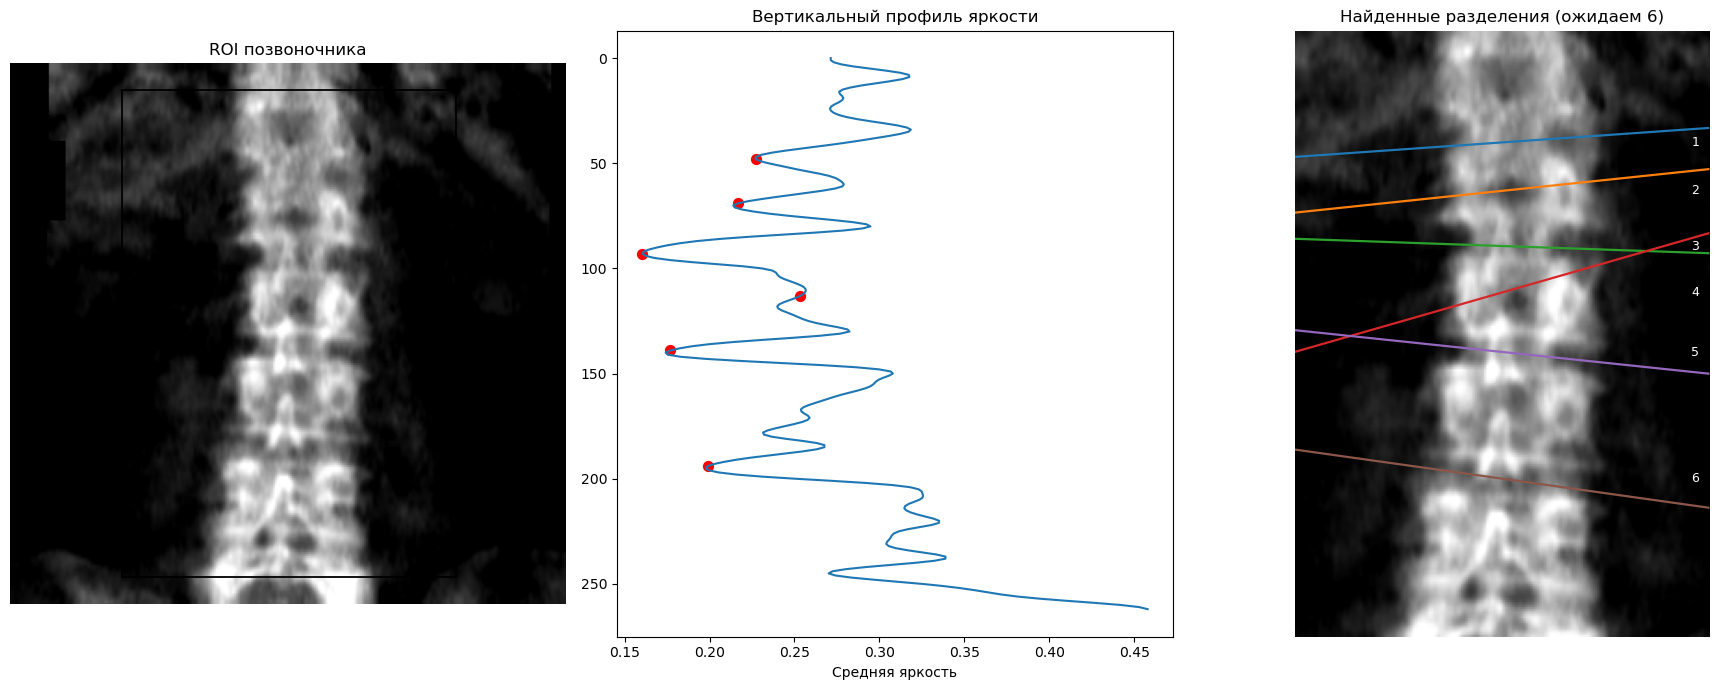

Найдено разделений: 6 (ожидается 6)


,separator_idx,y,angle,darkness_score
0,1,48.0,-4.0,0.247693
1,2,69.0,-6.0,0.240459
2,3,93.0,2.0,0.189633
3,4,113.0,-16.0,0.278757
4,5,139.0,6.0,0.194580
5,6,194.0,8.0,0.218277


,y,brightness,prominence
0,24,0.270896,0.046768
1,48,0.227132,0.051942
2,70,0.213967,0.080751
3,93,0.160463,0.158038
4,118,0.239859,0.016785
5,140,0.174149,0.108235
6,167,0.253794,0.005126
7,178,0.231499,0.036125
8,195,0.197794,0.110120
9,214,0.314641,0.011036



1.2.840.113619.2.110.512719.20250403090444/series_004_3_CR/DXA/CR DXA/CR000000.dcm


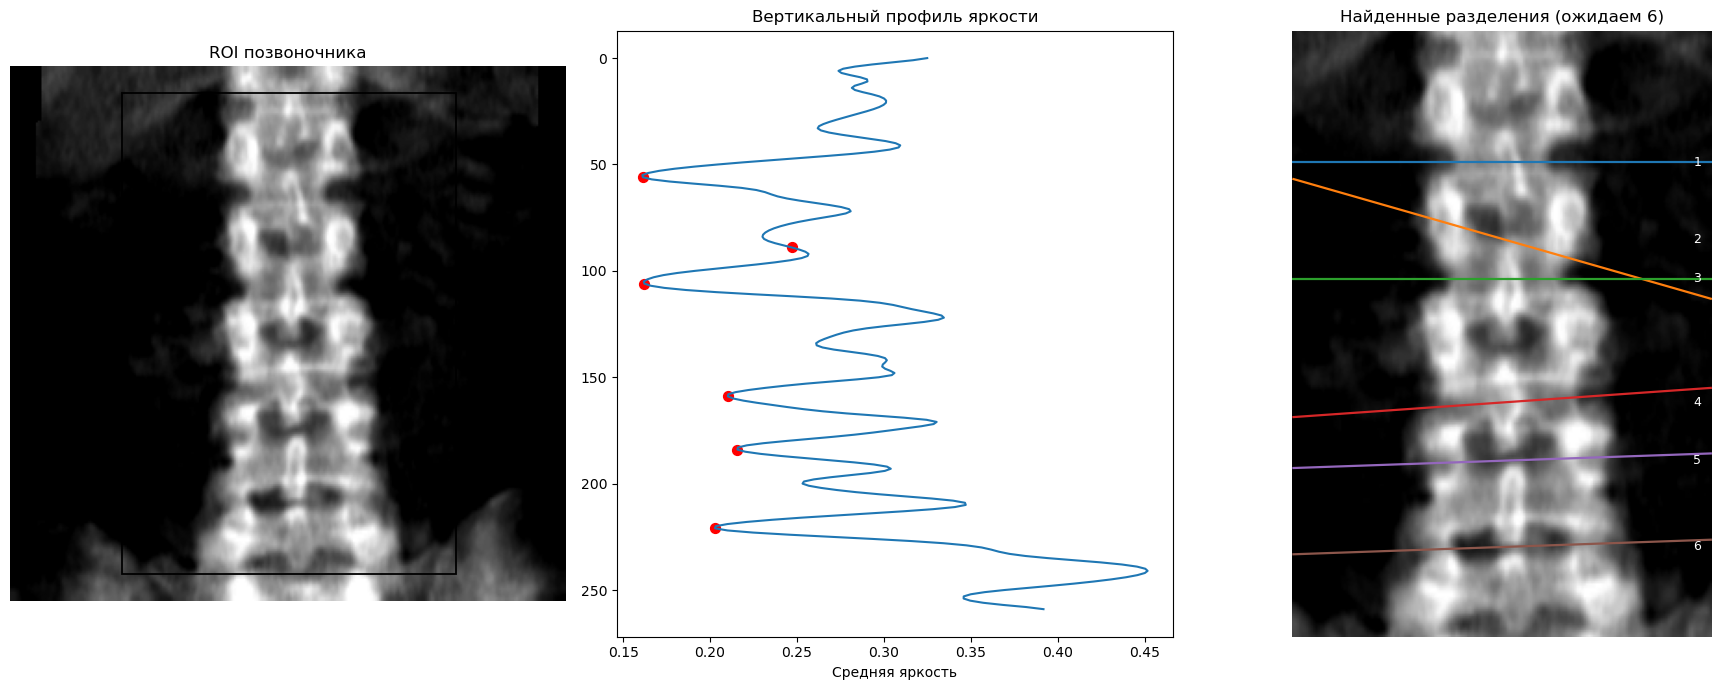

Найдено разделений: 6 (ожидается 6)


,separator_idx,y,angle,darkness_score
0,1,56.0,0.0,0.185693
1,2,89.0,16.0,0.263718
2,3,106.0,0.0,0.189740
3,4,159.0,-4.0,0.240434
4,5,184.0,-2.0,0.251288
5,6,221.0,-2.0,0.231736


,y,brightness,prominence
0,6,0.273823,0.027400
1,33,0.261865,0.047472
2,55,0.161061,0.163784
3,84,0.230109,0.026495
4,105,0.161876,0.118968
5,134,0.260975,0.045040
6,159,0.210189,0.124232
7,184,0.215716,0.114551
8,200,0.253135,0.050759
9,221,0.202792,0.144217



2.25.158646777318759504110695916200521633609/series_004_2_CR/A2507266260 DXA/CR DXA/CR000005.dcm


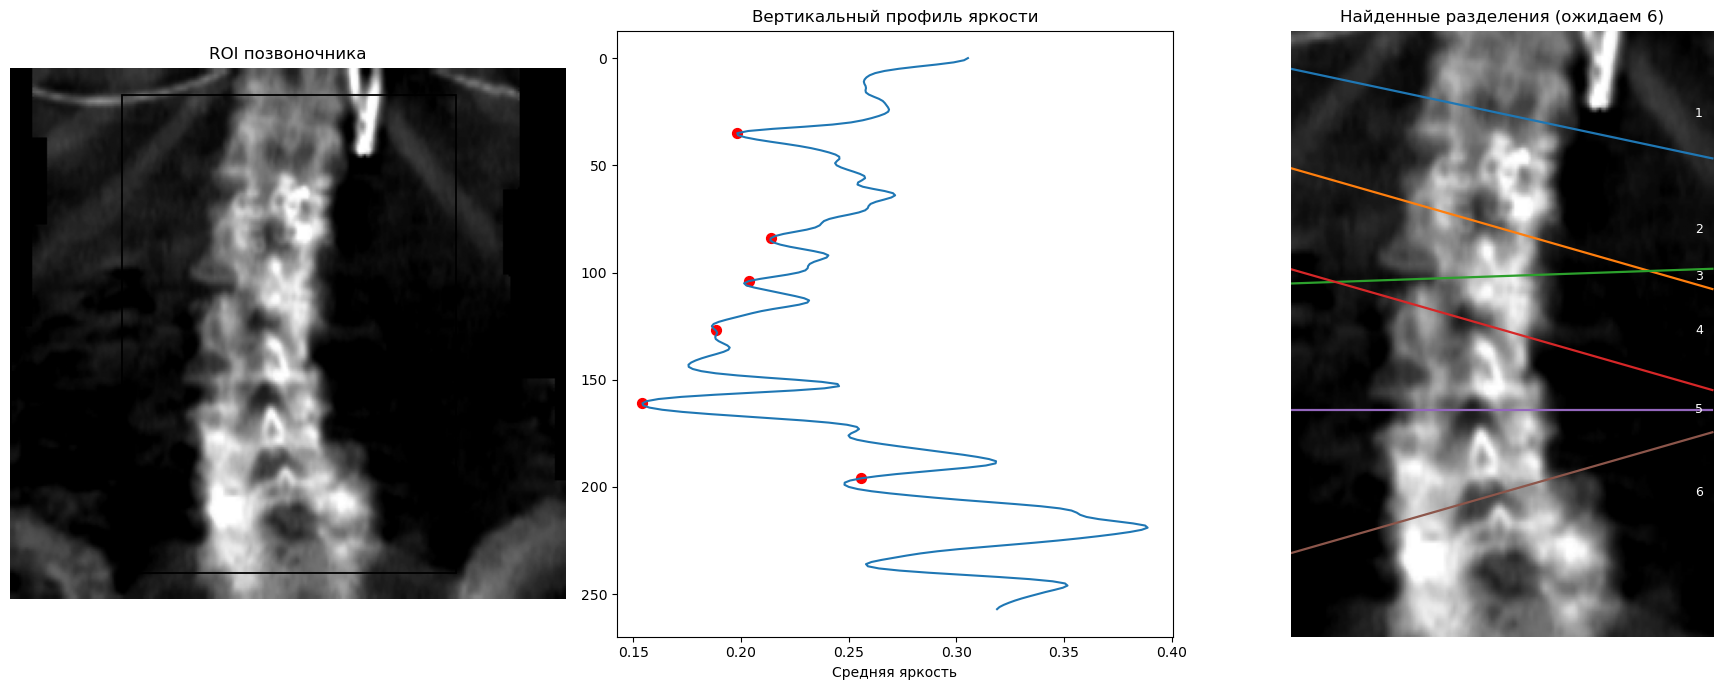

Найдено разделений: 6 (ожидается 6)


,separator_idx,y,angle,darkness_score
0,1,35.0,12.0,0.185010
1,2,84.0,16.0,0.225139
2,3,104.0,-2.0,0.233444
3,4,127.0,16.0,0.188058
4,5,161.0,0.0,0.182645
5,6,196.0,-16.0,0.266950


,y,brightness,prominence
0,11,0.257048,0.011713
1,35,0.198312,0.073271
2,85,0.213664,0.026940
3,105,0.201497,0.030163
4,125,0.186516,0.008292
5,143,0.175670,0.069872
6,161,0.154273,0.151101
7,176,0.249934,0.004886
8,199,0.248072,0.070341
9,236,0.258054,0.093525


In [17]:
spine_examples = pd.DataFrame()

if len(labels_df):
    spine_pool = labels_df[labels_df["label"] == "SPINE"]

    if len(spine_pool):
        spine_examples = spine_pool.sample(
            min(3, len(spine_pool)), random_state=SEED
        )

        for _, row in spine_examples.iterrows():
            print("\n", "=" * 100)
            print(row["relative_path"])

            separators, candidate_table = plot_spine_separators(row["dicom_path"])

            print(
                f"Найдено разделений: {len(separators)} "
                f"(ожидается {SPINE_N_SEPARATORS})"
            )

            display(pd.DataFrame([
                {
                    "separator_idx": i + 1,
                    "y": s["y"],
                    "angle": s["angle"],
                    "darkness_score": s["score"],
                }
                for i, s in enumerate(separators)
            ]))

            if not candidate_table.empty:
                display(candidate_table)

## 10. Позвоночник — оси симметрии

Сначала находим **6 межпозвонковых разделений**, которые делят ROI на **7 сегментов**:
`T12`, `L1`, `L2`, `L3`, `L4`, `L5`, `крестец`.

Затем для каждого сегмента отдельно ищем ось зеркальной симметрии.

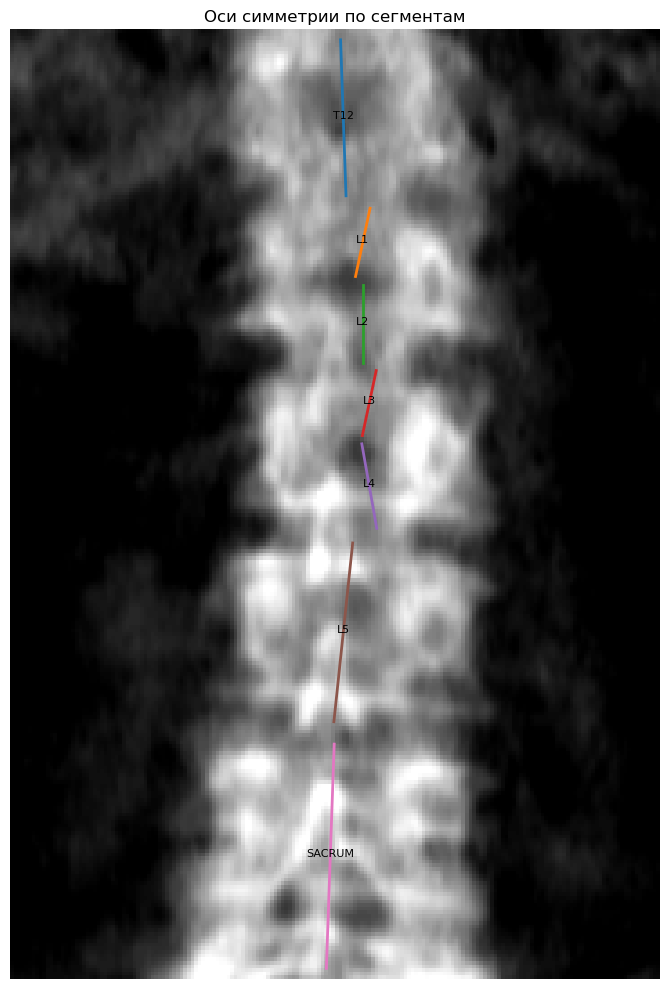

,segment_index,segment_name,y_top,y_bottom,y_center,x_center,vertical_angle,symmetry_error
0,0,T12,0,48,24.0,91.8,2.0,0.082284
1,1,L1,48,69,58.5,97.2,-12.0,0.089032
2,2,L2,69,93,81.0,97.2,0.0,0.059980
3,3,L3,93,113,103.0,99.0,-12.0,0.048579
4,4,L4,113,139,126.0,99.0,10.0,0.067764
5,5,L5,139,194,166.5,91.8,-6.0,0.076674
6,6,SACRUM,194,263,228.5,88.2,-2.0,0.064200


In [18]:
def symmetry_error_about_x(strip, x_center):
    h, w = strip.shape
    x_center = int(round(x_center))

    radius = min(x_center, w - x_center - 1)

    if radius < 5:
        return np.inf

    left = strip[:, x_center - radius:x_center]
    right = strip[:, x_center + 1:x_center + 1 + radius]

    radius = min(left.shape[1], right.shape[1])
    left = left[:, -radius:]
    right = right[:, :radius]

    return float(np.mean(np.abs(left - np.fliplr(right))))


def find_strip_symmetry(strip, angle_candidates=np.arange(-12, 13, 2)):
    best = None

    for angle in angle_candidates:
        rotated = ndi_rotate(
            strip,
            angle=-angle,
            reshape=False,
            order=1,
            mode="nearest",
        )

        w = rotated.shape[1]

        for x_center in np.linspace(w * 0.35, w * 0.65, 31):
            score = symmetry_error_about_x(rotated, x_center)

            candidate = {
                "vertical_angle": float(angle),
                "x_center": float(x_center),
                "score": score,
            }

            if best is None or score < best["score"]:
                best = candidate

    return best


def build_vertebra_symmetry_table(roi, separators):
    rows = []
    ys = sorted(int(round(s["y"])) for s in separators)

    boundaries = [0] + ys + [roi.shape[0]]

    for i, (y_top, y_bottom) in enumerate(zip(boundaries[:-1], boundaries[1:])):
        if y_bottom - y_top < 8:
            continue

        strip = roi[y_top:y_bottom]
        result = find_strip_symmetry(strip)

        if result is None:
            continue

        segment_name = (
            SPINE_SEGMENT_NAMES[i]
            if i < len(SPINE_SEGMENT_NAMES)
            else f"segment_{i}"
        )

        rows.append({
            "segment_index": i,
            "segment_name": segment_name,
            "y_top": y_top,
            "y_bottom": y_bottom,
            "y_center": (y_top + y_bottom) / 2,
            "x_center": result["x_center"],
            "vertical_angle": result["vertical_angle"],
            "symmetry_error": result["score"],
        })

    return pd.DataFrame(rows)


def plot_spine_symmetry(path):
    _, roi, _, _, _, separators = analyze_spine_separators(path)
    table = build_vertebra_symmetry_table(roi, separators)

    fig, ax = plt.subplots(figsize=(8, 10))
    ax.imshow(roi, cmap="gray")

    for _, row in table.iterrows():
        yc = row["y_center"]
        xc = row["x_center"]
        half = max(5, (row["y_bottom"] - row["y_top"]) * 0.45)
        dx = math.tan(math.radians(row["vertical_angle"])) * half

        ax.plot(
            [xc - dx, xc + dx],
            [yc - half, yc + half],
            linewidth=2,
        )
        ax.text(
            xc,
            yc,
            str(row["segment_name"]),
            fontsize=8,
            ha="center",
        )

    ax.set_title("Оси симметрии по сегментам")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

    return table


symmetry_table = pd.DataFrame()

if len(spine_examples):
    example = spine_examples.iloc[0]
    symmetry_table = plot_spine_symmetry(example["dicom_path"])
    display(symmetry_table)

### Верхний и нижний ориентиры

В текущей постановке рассматриваем 7 сегментов:
`T12`, `L1`, `L2`, `L3`, `L4`, `L5`, `SACRUM`.

Ниже можно посчитать:
- сумму локальных углов симметрии;
- подписанную сумму углов;
- угол линии между верхним и нижним ориентиром, например `T12` и `SACRUM`.

In [19]:
def angle_from_vertical(p1, p2):
    x1, y1 = p1
    x2, y2 = p2
    return float(np.rad2deg(np.arctan2(x2 - x1, y2 - y1)))


UPPER_SEGMENT_NAME = "T12"
LOWER_SEGMENT_NAME = "SACRUM"

if len(symmetry_table):
    print(
        "Сумма |углов симметрии|:",
        symmetry_table["vertical_angle"].abs().sum()
    )
    print(
        "Подписанная сумма:",
        symmetry_table["vertical_angle"].sum()
    )

    present_names = set(symmetry_table["segment_name"])

    if (
        UPPER_SEGMENT_NAME in present_names
        and LOWER_SEGMENT_NAME in present_names
    ):
        a = symmetry_table.loc[
            symmetry_table["segment_name"] == UPPER_SEGMENT_NAME
        ].iloc[0]
        b = symmetry_table.loc[
            symmetry_table["segment_name"] == LOWER_SEGMENT_NAME
        ].iloc[0]

        angle = angle_from_vertical(
            (a["x_center"], a["y_center"]),
            (b["x_center"], b["y_center"]),
        )

        print(
            f"Угол линии {UPPER_SEGMENT_NAME} → "
            f"{LOWER_SEGMENT_NAME} относительно вертикали:",
            angle
        )

Сумма |углов симметрии|: 44.0
Подписанная сумма: -20.0
Угол линии T12 → SACRUM относительно вертикали: -1.008525688070881


## 11. Позвоночник — позиция: сегментация подвздошных костей

Для обучения нужны отдельные маски.

Ожидаемый `iliac_masks.csv`:

```csv
relative_path,mask_path
2.25.../CR000000.dcm,C:/.../mask_000000.png
```

Маска: `0` — фон, `255` — подвздошные кости.

Используем U-Net с ImageNet-pretrained ResNet34 encoder. После инференса считаем `mask.mean()` — долю площади подвздошных костей.

In [20]:
try:
    import segmentation_models_pytorch as smp
except ImportError:
    smp = None

SEG_SIZE = 256
SEG_BATCH_SIZE = 4
SEG_EPOCHS = 8


class IliacSegmentationDataset(Dataset):
    def __init__(self, frame):
        self.frame = frame.reset_index(drop=True)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]

        image = dicom_to_pil(row["dicom_path"]).resize((SEG_SIZE, SEG_SIZE))
        mask = Image.open(row["mask_path"]).convert("L").resize(
            (SEG_SIZE, SEG_SIZE),
            resample=Image.Resampling.NEAREST,
        )

        image = T.ToTensor()(image)
        image = T.Normalize(IMAGENET_MEAN, IMAGENET_STD)(image)

        mask = np.asarray(mask, dtype=np.float32) / 255.0
        mask = torch.from_numpy((mask > 0.5).astype(np.float32)).unsqueeze(0)

        return image, mask


def dice_loss_from_logits(logits, target, eps=1e-6):
    probs = torch.sigmoid(logits)
    intersection = (probs * target).sum(dim=(1, 2, 3))
    union = probs.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
    dice = (2 * intersection + eps) / (union + eps)
    return 1 - dice.mean()


def segmentation_loss(logits, target):
    bce = nn.functional.binary_cross_entropy_with_logits(logits, target)
    return bce + dice_loss_from_logits(logits, target)


def train_segmentation_model(train_frame, val_frame):
    if smp is None:
        raise RuntimeError("segmentation_models_pytorch не установлен")

    model = smp.Unet(
        encoder_name="resnet34",
        encoder_weights="imagenet",
        in_channels=3,
        classes=1,
    ).to(DEVICE)

    train_loader = DataLoader(
        IliacSegmentationDataset(train_frame),
        batch_size=SEG_BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
    )
    val_loader = DataLoader(
        IliacSegmentationDataset(val_frame),
        batch_size=SEG_BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
    )

    optimizer = torch.optim.AdamW(
        model.parameters(), lr=2e-4, weight_decay=1e-4
    )

    history = []

    for epoch in range(SEG_EPOCHS):
        model.train()
        train_losses = []

        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)

            logits = model(x)
            loss = segmentation_loss(logits, y)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        model.eval()
        val_losses = []

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                val_losses.append(
                    segmentation_loss(model(x), y).item()
                )

        row = {
            "epoch": epoch + 1,
            "train_loss": float(np.mean(train_losses)),
            "val_loss": float(np.mean(val_losses)),
        }
        history.append(row)
        print(row)

    return model, pd.DataFrame(history)

In [21]:
iliac_model = None
iliac_val = pd.DataFrame()

if ILIAC_MASKS_CSV.exists():
    iliac_df = pd.read_csv(ILIAC_MASKS_CSV, dtype=str).fillna("")

    required = {"relative_path", "mask_path"}
    if not required.issubset(iliac_df.columns):
        raise ValueError("Нужны columns: relative_path, mask_path")

    iliac_df["dicom_path"] = iliac_df["relative_path"].map(
        relative_to_local_path
    )
    iliac_df = iliac_df[
        iliac_df["dicom_path"].map(Path.exists)
        & iliac_df["mask_path"].map(lambda p: Path(p).exists())
    ].copy()

    iliac_df["study_id"] = iliac_df["relative_path"].map(
        lambda x: normalize_relative_path(x).parts[0]
    )

    if len(iliac_df) >= 8:
        splitter = GroupShuffleSplit(
            n_splits=1, test_size=0.2, random_state=SEED
        )
        tr_idx, va_idx = next(
            splitter.split(iliac_df, groups=iliac_df["study_id"])
        )

        iliac_train = iliac_df.iloc[tr_idx].reset_index(drop=True)
        iliac_val = iliac_df.iloc[va_idx].reset_index(drop=True)

        iliac_model, iliac_history = train_segmentation_model(
            iliac_train, iliac_val
        )
        display(iliac_history)

        torch.save(
            iliac_model.state_dict(),
            WORK_DIR / "unet_iliac_bones.pt",
        )
    else:
        print("Недостаточно размеченных масок.")
else:
    print("iliac_masks.csv пока отсутствует — этот раздел пропускается.")

iliac_masks.csv пока отсутствует — этот раздел пропускается.


In [22]:
@torch.no_grad()
def predict_iliac_mask(model, dicom_path, threshold=0.5):
    pil = dicom_to_pil(dicom_path).resize((SEG_SIZE, SEG_SIZE))

    x = T.ToTensor()(pil)
    x = T.Normalize(IMAGENET_MEAN, IMAGENET_STD)(x)
    x = x.unsqueeze(0).to(DEVICE)

    prob = torch.sigmoid(model(x))[0, 0].cpu().numpy()
    mask = prob >= threshold
    area_fraction = float(mask.mean())

    return np.asarray(pil), prob, mask, area_fraction


def show_iliac_prediction(model, dicom_path):
    img, prob, mask, area_fraction = predict_iliac_mask(
        model, dicom_path
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(img, cmap="gray")
    axes[0].set_title("DXA")
    axes[0].axis("off")

    axes[1].imshow(prob, cmap="gray")
    axes[1].set_title("P(iliac bone)")
    axes[1].axis("off")

    axes[2].imshow(img, cmap="gray")
    axes[2].imshow(mask, alpha=0.35)
    axes[2].set_title(f"Area fraction={area_fraction:.3f}")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    return area_fraction


if iliac_model is not None:
    results = []

    for _, row in iliac_val.head(5).iterrows():
        fraction = show_iliac_prediction(
            iliac_model, row["dicom_path"]
        )
        results.append({
            "relative_path": row["relative_path"],
            "iliac_area_fraction": fraction,
        })

    display(pd.DataFrame(results))

## 12. Что смотреть в первом прогоне

На первых 5–10 изображениях отдельно калибруем:

1. `BACKGROUND_THRESHOLD_SCALE`.
2. `HIP_ROIS`.
3. `HIP_EXPECTED_ANGLES`.
4. `HIP_ANGLE_TOLERANCE`.
5. диапазон углов межпозвонковых разделений.
6. ROI позвоночника.
7. будущий порог по `iliac_area_fraction`.

Артефакты обучения сохраняются в `prototype_output/`.

Порог по доле подвздошных костей специально не задан: по идее из заметок он должен быть подобран по данным.